In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from scipy.interpolate import splprep, splev
import random

from scipy.spatial import cKDTree

# Helpers

In [2]:
def normalize(vector):
    norm = np.linalg.norm(vector)

    if norm == 0:
        raise ValueError("Cannot normalize a zero vector")
    
    return vector / norm

def sample_direction_in_cone(rng, axis, max_angle_deg):
    axis = normalize(axis)

    max_angle_rad = np.deg2rad(max_angle_deg)

    cos_alpha = rng.uniform(np.cos(max_angle_rad), 1.0)
    sin_alpha = np.sqrt(1.0 - cos_alpha**2)
    phi = rng.uniform(0.0, 2.0 * np.pi)

    if abs(axis[2] < 0.9):
        reference = np.array([0.0, 0.0, 1.0])
    else:
        reference = np.array([1.0, 0.0, 0.0])

    u = normalize(np.cross(axis, reference))
    v = np.cross(axis, u)

    direction = (
        cos_alpha * axis
        + sin_alpha * np.cos(phi) * u
        + sin_alpha * np.sin(phi) * v
    )

    return normalize(direction)

# Generate backbone

In [25]:
@dataclass
class BackboneConfig:
    mode: str = "straight" #"straight" or "perturbed"
    seed: int = 42
    step_size: float = 1.0 # distance between two consecutive points in the backbone
    max_angle_deg: float = 10.0 # maximuam angular deviation
    smoothness: float = 0.5 
    direction_mode: str = "previous" # "previous" or "cone"
    perturbation_probability: float = 0.5


def generate_straight_backbone(n_points, step_size = 1.0):
    point_index = np.arange(n_points)

    return pd.DataFrame({
        "point_index": point_index,
        "center_x": np.zeros(n_points),
        "center_y": np.zeros(n_points),
        "center_z": point_index * step_size,
    })


def generate_perturbed_backbone(
        n_points,
        seed = 0,
        step_size = 1.0,
        initial_direction = (0.0, 0.0, 1.0),
        max_angle_deg = 10.0,
        smoothness = 0.8,
        perturbation_probability = 0.5,
):
    rng = np.random.default_rng(seed)

    points = np.zeros((n_points, 3))

    direction = np.array(initial_direction, dtype = float)
    direction = direction / np.linalg.norm(direction)

    max_angle_rad = np.deg2rad(max_angle_deg)

    for i in range(1, n_points):
        if rng.random() > perturbation_probability:
            candidate_direction = sample_direction_in_cone(
                rng = rng,
                axis = direction,
                max_angle_deg = max_angle_deg,
            )

            direction = (
                smoothness * direction
                + (1.0 - smoothness) * candidate_direction
            )

            direction = normalize(direction)

        points[i] = points[i-1] + step_size * direction

    return pd.DataFrame({
        "points_index": np.arange(n_points),
        "center_x": points[:, 0],
        "center_y": points[:, 1],
        "center_z": points[:, 2],
    })

def generate_backbone(n_points, config):
    if config.mode == "straight":
        return generate_straight_backbone(
            n_points = n_points,
            step_size = config.step_size,
        )
    
    if config.mode == "perturbed":
        return generate_perturbed_backbone(
            n_points = n_points,
            seed = config.seed,
            step_size = config.step_size,
            max_angle_deg = config.max_angle_deg,
            smoothness = config.smoothness,
            perturbation_probability= config.perturbation_probability,
        )
    
    raise ValueError(f"Unknown backbone mode: {config.mode}")



# Visualize backbone

In [26]:
def plot_backbone_3d(backbone):
    fig = plt.figure(figsize =(7, 7))
    ax = fig.add_subplot(111, projection = "3d")

    ax.plot(
        backbone["center_x"],
        backbone["center_y"],
        backbone["center_z"],
        linewidth = 2,
        label = "backbone",
    )

    ax.scatter(
        backbone["center_x"],
        backbone["center_y"],
        backbone["center_z"],
        s = 20,
        alpha = 0.8,
    )

    ax.scatter(
        backbone["center_x"].iloc[0],
        backbone["center_y"].iloc[0],
        backbone["center_z"].iloc[0],
        color="green",
        s=80,
        label="start",
    )

    ax.scatter(
        backbone["center_x"].iloc[-1],
        backbone["center_y"].iloc[-1],
        backbone["center_z"].iloc[-1],
        color="red",
        s=80,
        label="end",
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()

In [5]:
backbone_config = BackboneConfig(
    mode="straight",
    step_size=0.5,
)


backbone = generate_backbone(
    n_points=helix.n_points,
    config=backbone_config,
)

plot_backbone_3d(backbone)

NameError: name 'helix' is not defined

In [6]:
backbone_config = BackboneConfig(
    mode="straight",
    seed=42,
    step_size=0.5,
    max_angle_deg=10,
    smoothness = 0.5,
    perturbation_probability = 0.7,
    
)

backbone = generate_backbone(
    n_points=helix.n_points,
    config=backbone_config,
)

plot_backbone_3d(backbone)

NameError: name 'helix' is not defined

# Generate helix points

In [27]:
def resample_backbone_by_rise(backbone, rise):
    centers = backbone[["center_x", "center_y", "center_z"]].to_numpy()

    segment_vectors = np.diff(centers, axis = 0)
    segment_lengths = np.linalg.norm(segment_vectors, axis = 1)

    arc_length = np.concatenate([
        [0.0],
        np.cumsum(segment_lengths),

    ])
    total_length = arc_length[-1]

    target_arc_length = np.arange(0.0, total_length + 1e-9,  rise)

    if target_arc_length[-1] > arc_length[-1]:
        raise ValueError(
            "Backbone is too short for the requested rise and number of helix points"
        )
    
    resampled_x = np.interp(target_arc_length, arc_length, centers[:, 0])
    resampled_y = np.interp(target_arc_length, arc_length, centers[:, 1])
    resampled_z = np.interp(target_arc_length, arc_length, centers[:, 2])

    return pd.DataFrame({
        "point_index": np.arange(len(target_arc_length)),
        "center_x": resampled_x,
        "center_y": resampled_y,
        "center_z": resampled_z,
        "arc_length": target_arc_length,
    })

def compute_backbone_frames(backbone):
    centers = backbone[["center_x", "center_y", "center_z"]].to_numpy()

    tangents = np.gradient(centers, axis = 0)
    tangents = np.array([normalize(t) for t in tangents])

    

    normals = []
    binormals = []

    for tangent in tangents:
        reference = np.array([1.0, 0.0, 0.0])
        if abs(np.dot(tangent, reference)) > 0.9:
            reference = np. array([0.0, 1.0, 0.0])
        
        normal = reference - np.dot(reference, tangent) * tangent
        normal = normalize(normal)

        binormal = np.cross(tangent, normal)
        binormal = normalize(binormal)

        normals.append(normal)
        binormals.append(binormal)

    normals = np.array(normals)
    binormals = np.array(binormals)

    framed_backbone = backbone.copy()

    framed_backbone["tx"] = tangents[:, 0]
    framed_backbone["ty"] = tangents[:, 1]
    framed_backbone["tz"] = tangents[:, 2]

    framed_backbone["nx"] = normals[:, 0]
    framed_backbone["ny"] = normals[:, 1]
    framed_backbone["nz"] = normals[:, 2]

    framed_backbone["bx"] = binormals[:, 0]
    framed_backbone["by"] = binormals[:, 1]
    framed_backbone["bz"] = binormals[:, 2]

    return framed_backbone

def compute_parallel_transport_frames(backbone, initial_normal = (1.0, 0.0, 0.0)):
    centers = backbone[["center_x", "center_y", "center_z"]].to_numpy()

    tangents = np.gradient(centers, axis = 0)
    tangents = np.array([normalize(t) for t in tangents])

    initial_normal = np.array(initial_normal, dtype = float)

    normal = initial_normal - np.dot(initial_normal, tangents[0]) * tangents[0]

    if np.linalg.norm(normal) < 1e-8:
        initial_normal = np.array([0.0, 1.0, 0.0])
        normal = initial_normal - np.dot(initial_normal, tangents[0]) * tangents[0]

    normal = normalize(normal)

    normals = [normal]
    binormals = [normalize(np.cross(tangents[0], normal))]

    for i in range(1, len(tangents)):
        previous_tangent = tangents[i - 1]
        current_tangent = tangents[i]

        rotation_axis = np.cross(previous_tangent, current_tangent)
        rotation_axis_norm = np.linalg.norm(rotation_axis)

        if rotation_axis_norm < 1e-8:
            normal = normals[-1]
        else:
            rotation_axis = rotation_axis / rotation_axis_norm
            angle = np.arctan2(
                rotation_axis_norm,
                np.dot(previous_tangent, current_tangent)
            )

            previous_normal = normals[-1]

            normal = (
                previous_normal * np.cos(angle)
                + np.cross(rotation_axis, previous_normal) * np.sin(angle)
                + rotation_axis * np.dot(rotation_axis, previous_normal) * (1 - np.cos(angle))
            )

            normal = normal - np.dot(normal, current_tangent) * current_tangent
            normal = normalize(normal)

        binormal = normalize(np.cross(current_tangent, normal))
        
        normals.append(normal)
        binormals.append(binormal)

    normals = np.array(normals)
    binormals = np.array(binormals)

    framed_backbone = backbone.copy()

    framed_backbone["tx"] = tangents[:, 0]
    framed_backbone["ty"] = tangents[:, 1]
    framed_backbone["tz"] = tangents[:, 2]

    framed_backbone["nx"] = normals[:, 0]
    framed_backbone["ny"] = normals[:, 1]
    framed_backbone["nz"] = normals[:, 2]

    framed_backbone["bx"] = binormals[:, 0]
    framed_backbone["by"] = binormals[:, 1]
    framed_backbone["bz"] = binormals[:, 2]

    return framed_backbone



In [8]:
@dataclass
class RadiusVariationConfig:
    enabled: bool = False
    seed: int = 0
    n_control_points: int = 6
    min_radius: float = 1.5
    max_radius: float = 2.5
    smooth_window: int = 9

def generate_smooth_radius_profile(
        n_points,
        base_radius,
        config,
):
    if not config.enabled:
        return np.full(n_points, base_radius)
    
    rng = np.random.default_rng(config.seed)

    control_indices = np.linspace(
        0,
        n_points - 1,
        config.n_control_points,
        dtype = int,
    )

    control_radii = rng.uniform(
        low = base_radius * config.min_radius,
        high = base_radius * config.max_radius,
        size = config.n_control_points,
    )

    control_radii[0] = base_radius
    control_radii[-1] = base_radius

    point_index = np.arange(n_points)

    radius_profile = np.interp(
        point_index,
        control_indices,
        control_radii,
    )

    if config.smooth_window > 1:
        window = np.ones(config.smooth_window) / config.smooth_window

        radius_profile = np.convolve(
            radius_profile,
            window,
            mode = "same",
        )

    radius_profile = np.clip(
        radius_profile,
        config.min_radius,
        config.max_radius,
    )

    return radius_profile



In [28]:
@dataclass
class Strand:
    name: str
    radius: float
    phase_deg: float = 0.0

@dataclass
class Helix:
    twist_deg: float
    rise: float
    strands: list[Strand]
    backbone: pd.DataFrame
    radius_variation: RadiusVariationConfig = field(
        default_factory=RadiusVariationConfig
    )

    n_points: int = field(init=False)
    n_turns: float = field(init=False)
    total_length: float = field(init=False)  
    pitch: float = field(init=False)
    sampled_backbone: pd.DataFrame = field(init=False)
    framed_backbone: pd.DataFrame = field(init=False)
    points: pd.DataFrame = field(init=False)

    def __post_init__(self):

        self.sampled_backbone = resample_backbone_by_rise(
            backbone=self.backbone,
            rise=self.rise,
        )

        self.n_points = len(self.sampled_backbone)
        self.total_length = self.sampled_backbone["arc_length"].iloc[-1]
        self.n_turns = abs(self.twist_deg) * (self.n_points - 1) / 360
        self.pitch = self.rise * 360 / abs(self.twist_deg)
        
        self.framed_backbone = compute_parallel_transport_frames(self.sampled_backbone)
        self.points = self._generate_points()

    def _generate_points(self):
        all_points = []
        
        point_index = np.arange(self.n_points)

        centers = self.framed_backbone[["center_x", "center_y", "center_z"]].to_numpy()
        normals = self.framed_backbone[["nx", "ny", "nz"]].to_numpy()
        binormals = self.framed_backbone[["bx", "by", "bz"]].to_numpy()
        tangents = self.framed_backbone[["tx", "ty", "tz"]].to_numpy()

        for strand in self.strands:
            theta_deg = point_index * self.twist_deg + strand.phase_deg
            theta_rad = np.deg2rad(theta_deg)
            
            radius_profile = generate_smooth_radius_profile(
                n_points = self.n_points,
                base_radius = strand.radius,
                config = self.radius_variation,
            )

            offsets = (
                radius_profile[:, None] * np.cos(theta_rad)[:, None] * normals
                + radius_profile[:, None] * np.sin(theta_rad)[:, None] * binormals
            )

            coordinates = centers + offsets

            strand_points = pd.DataFrame({
                "strand": strand.name,
                "point_index": point_index,
                "x": coordinates[:, 0],
                "y": coordinates[:, 1],
                "z": coordinates[:, 2],
                "center_x": centers[:, 0],
                "center_y": centers[:, 1],
                "center_z": centers[:, 2],
                "tx": tangents[:, 0],
                "ty": tangents[:, 1],
                "tz": tangents[:, 2],
                "nx": normals[:, 0],
                "ny": normals[:, 1],
                "nz": normals[:, 2],
                "bx": binormals[:, 0],
                "by": binormals[:, 1],
                "bz": binormals[:, 2],
                "theta_deg": theta_deg,
                "theta_rad": theta_rad,
                "arc_length": self.framed_backbone["arc_length"].to_numpy(),
                "radius": radius_profile,
            })

            all_points.append(strand_points)

        return pd.concat(all_points, ignore_index=True)


In [10]:
backbone

NameError: name 'backbone' is not defined

In [29]:
backbone_config = BackboneConfig(
    mode = "straight",
    seed = 42,
    step_size = 0.5,
    max_angle_deg = 40,
    smoothness = 0.8,
    perturbation_probability = 0.5,
)

backbone = generate_backbone(
    n_points = 400,
    config = backbone_config,
)

strands = [
    Strand(name = "A", radius = 2.0, phase_deg = 0.0),
    Strand(name = "B", radius = 2.0, phase_deg = 180.0),
]

radius_variation = RadiusVariationConfig(
    enabled = True,
    seed = 123,
    n_control_points = 8,
    min_radius = 2.,
    max_radius = 2.,
    smooth_window = 11,
)

helix = Helix(
    twist_deg = 48.8,
    rise = 10,
    strands = strands,
    backbone = backbone,
    radius_variation = radius_variation,
)

plot_helix_3d(helix.points)

NameError: name 'plot_helix_3d' is not defined

In [30]:
helix.points


,strand,point_index,x,y,z,center_x,center_y,center_z,tx,ty,...,nx,ny,nz,bx,by,bz,theta_deg,theta_rad,arc_length,radius
0,A,0,2.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,2.0
1,A,1,1.317379,1.504830e+00,10.0,0.0,0.0,10.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,48.8,0.851721,10.0,2.0
2,A,2,-0.264513,1.982431e+00,20.0,0.0,0.0,20.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,97.6,1.703441,20.0,2.0
3,A,3,-1.665842,1.106783e+00,30.0,0.0,0.0,30.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,146.4,2.555162,30.0,2.0
4,A,4,-1.930033,-5.243784e-01,40.0,0.0,0.0,40.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,195.2,3.406883,40.0,2.0
5,A,5,-0.876742,-1.797588e+00,50.0,0.0,0.0,50.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,244.0,4.258603,50.0,2.0
6,A,6,0.775031,-1.843726e+00,60.0,0.0,0.0,60.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,292.8,5.110324,60.0,2.0
7,A,7,1.897752,-6.312981e-01,70.0,0.0,0.0,70.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,341.6,5.962045,70.0,2.0
8,A,8,1.725027,1.012068e+00,80.0,0.0,0.0,80.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,390.4,6.813765,80.0,2.0
9,A,9,0.374763,1.964575e+00,90.0,0.0,0.0,90.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,439.2,7.665486,90.0,2.0


In [31]:
np.diff(helix.sampled_backbone["arc_length"])

array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10.])

# Degradation

In [32]:
@dataclass
class DegradationConfig:
    seed: int = 0
    noise_std: float = 0.0
    noise_fraction: float = 0.0
    missing_fraction: float = 0.0
    missing_mode: str = "global"
    strand_missing_mode: str = "uniform"
    max_gap_size: int = 5

def sample_missing_segments_for_strand(strand_points, missing_fraction, max_gap_size, rng):
    strand_points = strand_points.sort_values("point_index")

    n_points = len(strand_points)
    n_missing_target = int(round(missing_fraction * n_points))

    missing_point_indices = set()
    point_indices = strand_points["point_index"].to_numpy()

    while len(missing_point_indices) < n_missing_target:
        gap_size = rng.integers(1, max_gap_size + 1)
        start_position = rng.integers(0, n_points)

        
        segment = point_indices[start_position:start_position + gap_size]

        for point_index in segment:
            missing_point_indices.add(point_index)

        if len(missing_point_indices) >= n_missing_target:
            break

    missing_point_indices = set(
        list(missing_point_indices)[:n_missing_target]
    )

    return strand_points[
        strand_points["point_index"].isin(missing_point_indices)
    ].index

def get_strand_missing_fractions(
        n_strands,
        missing_fraction,
        strand_missing_mode,
        rng
):
    if strand_missing_mode =="uniform":
        return np.full(n_strands, missing_fraction)
    
    if strand_missing_mode == "random":
        weights = rng.dirichlet(np.ones(n_strands))
        return missing_fraction * weights
    
    raise ValueError(
        f"Unkown_strand_missing_mode: {strand_missing_mode}"
    )

def sample_missing_indices(
    strand_points,
    missing_fraction,
    missing_mode,
    max_gap_size,
    rng,
):
    if missing_mode == "per_strand":
        n_missing = int(round(missing_fraction * len(strand_points)))

        if n_missing == 0:
            
            return strand_points.index[0]
        
        return rng.choice(
            strand_points.index,
            size = n_missing,
            replace = False,
        )
    
    if missing_mode == "segments_per_strand":
        missing_mask = sample_missing_segments_for_strand(
            strand_points=strand_points,
            missing_fraction=missing_fraction,
            max_gap_size=max_gap_size,
            rng=rng,
        )

        # Convertimos la máscara local en índices del DataFrame original
        return missing_mask

    raise ValueError(f"Unknown missing_mode: {missing_mode}")

def add_point_ids(points):
    points = points.copy()

    points["point_id"] = (
        points["strand"].astype(str)
        + "_"
        + points["point_index"].astype(str)
    )

    return points

def validate_point_ids(input_points, target_points, missing_points):
    assert target_points["point_id"].is_unique
    assert input_points["point_id"].is_unique
    assert missing_points["point_id"].is_unique

    input_ids = set(input_points["point_id"])
    missing_ids = set(missing_points["point_id"])
    target_ids = set(target_points["point_id"])

    assert input_ids.isdisjoint(missing_ids)
    assert input_ids | missing_ids == target_ids

    return {
        "n_target": len(target_points),
        "n_input": len(input_points),
        "n_missing": len(missing_points),
        "ids_are_valid": True,
    }


def build_strand_metadata(helix, target_points):
    rows = []

    phase_by_strand = {
        strand.name: strand.phase_deg
        for strand in helix.strands
    }

    for strand_name, strand_points in target_points.groupby("strand"):
        strand_points = strand_points.sort_values("point_index")

        radius_values = strand_points["radius"].to_numpy()

        rows.append({
            "strand": strand_name,
            "phase_deg": phase_by_strand[strand_name],
            "target_global_rise": helix.rise,
            "target_global_twist_deg": helix.twist_deg,
            "target_global_pitch": helix.pitch,
            "target_global_n_turns": helix.n_turns,
            "n_points": len(strand_points),
            "n_observed": int(strand_points["is_observed"].sum()),
            "n_missing": int(strand_points["is_missing"].sum()),
            "n_noisy": int(strand_points["is_noisy"].sum()),
            "missing_fraction_actual": float(strand_points["is_missing"].mean()),
            "noise_fraction_actual": float(strand_points["is_noisy"].mean()),
            "radius_mean": float(np.mean(radius_values)),
            "radius_min": float(np.min(radius_values)),
            "radius_max": float(np.max(radius_values)),
        })

    return pd.DataFrame(rows)

#Check this, maybe not usefull
def build_target_segments(target_points):
    rows = []

    for strand_name, strand_points in target_points.groupby("strand"):
        strand_points = strand_points.sort_values("point_index")

        for i in range(len(strand_points) - 1):
            point_i = strand_points.iloc[i]
            point_j = strand_points.iloc[i + 1]

            position_i = np.array([
                point_i["x_clean"],
                point_i["y_clean"],
                point_i["z_clean"],
            ])

            position_j = np.array([
                point_j["x_clean"],
                point_j["y_clean"],
                point_j["z_clean"],
            ])

            rows.append({
                "strand": strand_name,
                "point_id_i": point_i["point_id"],
                "point_id_j": point_j["point_id"],
                "point_index_i": int(point_i["point_index"]),
                "point_index_j": int(point_j["point_index"]),
                "arc_length_i": point_i["arc_length"],
                "arc_length_j": point_j["arc_length"],
                "local_rise": point_j["arc_length"] - point_i["arc_length"],
                "theta_deg_i": point_i["theta_deg"],
                "theta_deg_j": point_j["theta_deg"],
                "local_twist_deg": point_j["theta_deg"] - point_i["theta_deg"],
                "radius_i": point_i["radius"],
                "radius_j": point_j["radius"],
                "distance_3d": np.linalg.norm(position_j - position_i),
                "is_i_observed": bool(point_i["is_observed"]),
                "is_j_observed": bool(point_j["is_observed"]),
                "is_i_missing": bool(point_i["is_missing"]),
                "is_j_missing": bool(point_j["is_missing"]),
                "segment_is_observed": bool(point_i["is_observed"] and point_j["is_observed"]),
                "segment_has_missing": bool(point_i["is_missing"] or point_j["is_missing"]),
            })

    return pd.DataFrame(rows)

def add_local_backbone_coordinates(target_points):
    points = target_points.copy()

    positions = points[["x_clean", "y_clean", "z_clean"]].to_numpy()
    centers = points[["center_x", "center_y", "center_z"]].to_numpy()
    normals = points[["nx", "ny", "nz"]].to_numpy()
    binormals = points[["bx", "by", "bz"]].to_numpy()

    radial_vectors = positions - centers

    points["local_n"] = np.sum(radial_vectors * normals, axis = 1)
    points["local_b"] = np.sum(radial_vectors * binormals, axis = 1)
    points["local_radius"] = np.linalg.norm(radial_vectors, axis = 1)
    points["local_angle_rad"] = np.arctan2(points["local_b"], points["local_n"])
    points["local_angle_deg"] = np.rad2deg(points["local_angle_rad"])

    return points

def build_target_segments_from_geometry(target_points):
    rows = []

    target_points = add_local_backbone_coordinates(target_points)

    for strand_name, strand_points in target_points.groupby("strand"):
        strand_points = strand_points.sort_values("point_index").copy()

        unwrapped_angle = np.unwrap(strand_points["local_angle_rad"].to_numpy())
        strand_points["local_angle_unwrapped_rad"] = unwrapped_angle

        for i in range(len(strand_points) - 1):
            point_i = strand_points.iloc[i]
            point_j = strand_points.iloc[i + 1]

            center_i = np.array([point_i["center_x"], point_i["center_y"], point_i["center_z"]])
            center_j = np.array([point_j["center_x"], point_j["center_y"], point_j["center_z"]])

            pos_i = np.array([point_i["x_clean"], point_i["y_clean"], point_i["z_clean"]])
            pos_j = np.array([point_j["x_clean"], point_j["y_clean"], point_j["z_clean"]])

            tangent_i = np.array([point_i["tx"], point_i["ty"], point_i["tz"]])
            tangent_j = np.array([point_j["tx"], point_j["ty"], point_j["tz"]])

            center_step = center_j - center_i
            local_rise = np.linalg.norm(center_step)

            tangent_dot = np.clip(np.dot(tangent_i, tangent_j), -1.0, 1.0)
            tangent_angle_rad = np.arccos(tangent_dot)

            local_twist_rad = (
                point_j["local_angle_unwrapped_rad"]
                - point_i["local_angle_unwrapped_rad"]
            )
            
            rows.append({
                "strand": strand_name,
                "point_id_i": point_i["point_id"],
                "point_id_j": point_j["point_id"],
                "point_index_i": int(point_i["point_index"]),
                "point_index_j": int(point_j["point_index"]),
                "target_local_rise": local_rise,
                "target_local_twist_deg":np.rad2deg(local_twist_rad),
                "target_local_twist_rad": local_twist_rad,
                "target_center_distance": local_rise,
                "target_point_distance_3d": np.linalg.norm(pos_j - pos_i),
                "target_local_radius_i": point_i["local_radius"],
                "target_local_radius_j": point_j["local_radius"],
                "target_backbone_tangent_angle_deg": np.rad2deg(tangent_angle_rad),
                "target_backbone_curvature_approx": tangent_angle_rad / local_rise if local_rise > 0 else 0.0,
                "is_i_observed": bool(point_i["is_observed"]),
                "is_j_observed": bool(point_j["is_observed"]),
                "segment_is_observed": bool(point_i["is_observed"] and point_j["is_observed"]),
                "segment_has_missing": bool(point_i["is_missing"] or point_j["is_missing"]),
            })

    return pd.DataFrame(rows)
                                


In [33]:

def degrade_helix_points(clean_points, config):
    rng = np.random.default_rng(config.seed)

    training_points = clean_points.copy()

    training_points["x_clean"] = training_points["x"]
    training_points["y_clean"] = training_points["y"]
    training_points["z_clean"] = training_points["z"]

    training_points["x_obs"] = training_points["x_clean"]
    training_points["y_obs"] = training_points["y_clean"]
    training_points["z_obs"] = training_points["z_clean"]

    training_points["noise_dx"] = 0.0
    training_points["noise_dy"] = 0.0
    training_points["noise_dz"] = 0.0
    training_points["noise_norm"] = 0.0

    training_points["is_noisy"] = False
    training_points["is_missing"] = False
    training_points["is_observed"] = True

    n_points = len(training_points)
    
    if config.noise_fraction > 0 and config.noise_std > 0:
        n_noisy = int(round(config.noise_fraction * n_points))

        noisy_indices = rng.choice(
            training_points.index,
            size = n_noisy,
            replace = False,
        )

        noise = rng.normal(
            loc = 0.0,
            scale = config.noise_std,
            size = (n_noisy, 3),
        )

        training_points.loc[noisy_indices, "x_obs"] += noise[:, 0]
        training_points.loc[noisy_indices, "y_obs"] += noise[:, 1]
        training_points.loc[noisy_indices, "z_obs"] += noise[:, 2]

        training_points.loc[noisy_indices, "noise_dx"] = noise[:, 0]
        training_points.loc[noisy_indices, "noise_dy"] = noise[:, 1]
        training_points.loc[noisy_indices, "noise_dz"] = noise[:, 2]
        training_points.loc[noisy_indices, "noise_norm"] = np.linalg.norm(noise, axis = 1)
        
        training_points.loc[noisy_indices, "is_noisy"] = True

    if config.missing_fraction > 0:
        match config.missing_mode:

            case "global":
                n_missing = int(round(config.missing_fraction * n_points))

                missing_indices = rng.choice(
                    training_points.index,
                    size = n_missing,
                    replace = False,
                )

                training_points.loc[missing_indices, "is_missing"] = True

            case "per_strand" | "segments_per_strand":
                strand_groups = list(
                    training_points.groupby("strand", sort = False)
                )
                

                missing_fractions = get_strand_missing_fractions(
                    n_strands = len(strand_groups),
                    missing_fraction = config.missing_fraction,
                    strand_missing_mode = config.strand_missing_mode,
                    rng = rng,
                )
                for (strand_name, strand_points), missing_fraction in zip(
                    strand_groups,
                    missing_fractions,
                ):
                    
                    missing_indices = sample_missing_indices(
                        strand_points = strand_points,
                        missing_fraction = missing_fraction,
                        missing_mode = config.missing_mode,
                        max_gap_size = config.max_gap_size,
                        rng =rng,
                    )

                    
                
                
                    training_points.loc[missing_indices, "is_missing"] = True
                #print(training_points[training_points["is_missing"]])
                
            case _:
                raise ValueError(f"Unknown missing_mode: {config.missing_mode}")
            
    training_points["is_observed"] = ~training_points["is_missing"]

    missing_mask = training_points["is_missing"]

    training_points.loc[missing_mask, ["x_obs", "y_obs", "z_obs"]] = np.nan
    training_points.loc[missing_mask, ["noise_dx", "noise_dy", "noise_dz", "noise_norm"]] = np.nan

    training_points = add_point_ids(training_points)

    input_points = training_points.loc[training_points["is_observed"]].copy()
    missing_points = training_points.loc[training_points["is_missing"]].copy()
    target_points = training_points.copy()


    
    degradation_info = {
        "seed": config.seed,
        "noise_std": config.noise_std,
        "noise_fraction_requested": config.noise_fraction,
        "missing_fraction_requested": config.missing_fraction,
        "missing_mode": config.missing_mode,
        "max_gap_size": config.max_gap_size,
        "n_clean_points": len(target_points),
        "n_input_points": len(input_points),
        "n_missing_points": len(missing_points),
        "n_noisy_points": int(target_points["is_noisy"].sum()),
        "noise_fraction_actual": float(target_points["is_noisy"].mean()),
        "missing_fraction_actual": float(target_points["is_missing"].mean()),
        "missing_by_strand":(
            missing_points.groupby("strand").size().to_dict()
            if len(missing_points) > 0
            else {}
        ),
        "noisy_by_strand":(
            target_points[target_points["is_noisy"]]
            .groupby("strand")
            .size()
            .to_dict()
        )
    }

    return input_points, target_points, missing_points, degradation_info



In [34]:
helix.points

,strand,point_index,x,y,z,center_x,center_y,center_z,tx,ty,...,nx,ny,nz,bx,by,bz,theta_deg,theta_rad,arc_length,radius
0,A,0,2.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,2.0
1,A,1,1.317379,1.504830e+00,10.0,0.0,0.0,10.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,48.8,0.851721,10.0,2.0
2,A,2,-0.264513,1.982431e+00,20.0,0.0,0.0,20.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,97.6,1.703441,20.0,2.0
3,A,3,-1.665842,1.106783e+00,30.0,0.0,0.0,30.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,146.4,2.555162,30.0,2.0
4,A,4,-1.930033,-5.243784e-01,40.0,0.0,0.0,40.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,195.2,3.406883,40.0,2.0
5,A,5,-0.876742,-1.797588e+00,50.0,0.0,0.0,50.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,244.0,4.258603,50.0,2.0
6,A,6,0.775031,-1.843726e+00,60.0,0.0,0.0,60.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,292.8,5.110324,60.0,2.0
7,A,7,1.897752,-6.312981e-01,70.0,0.0,0.0,70.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,341.6,5.962045,70.0,2.0
8,A,8,1.725027,1.012068e+00,80.0,0.0,0.0,80.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,390.4,6.813765,80.0,2.0
9,A,9,0.374763,1.964575e+00,90.0,0.0,0.0,90.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,439.2,7.665486,90.0,2.0


In [35]:


degradation_config = DegradationConfig(
    seed=342,
    noise_std=0.1,
    noise_fraction=0.5,
    missing_fraction=0.5,
    missing_mode="segments_per_strand",
    max_gap_size=6,
    strand_missing_mode = "random",
)

input_points, target_points, missing_points, degradation_info = degrade_helix_points(
    clean_points=helix.points,
    config=degradation_config,
)

validate_point_ids(
    input_points=input_points,
    target_points=target_points,
    missing_points=missing_points,
)

strand_metadata = build_strand_metadata(
    helix = helix,
    target_points = target_points,

)
strand_metadata

,strand,phase_deg,target_global_rise,target_global_twist_deg,target_global_pitch,target_global_n_turns,n_points,n_observed,n_missing,n_noisy,missing_fraction_actual,noise_fraction_actual,radius_mean,radius_min,radius_max
0,A,0.0,10,48.8,73.770492,2.575556,20,15,5,12,0.25,0.6,2.0,2.0,2.0
1,B,180.0,10,48.8,73.770492,2.575556,20,15,5,8,0.25,0.4,2.0,2.0,2.0


In [36]:
target_segments = build_target_segments_from_geometry(target_points)

target_segments[["strand", "point_index_i", "point_index_j", "target_local_rise", "target_local_twist_deg"]]

,strand,point_index_i,point_index_j,target_local_rise,target_local_twist_deg
0,A,0,1,10.0,48.8
1,A,1,2,10.0,48.8
2,A,2,3,10.0,48.8
3,A,3,4,10.0,48.8
4,A,4,5,10.0,48.8
5,A,5,6,10.0,48.8
6,A,6,7,10.0,48.8
7,A,7,8,10.0,48.8
8,A,8,9,10.0,48.8
9,A,9,10,10.0,48.8


In [37]:
input_points.groupby("strand").size()

strand
A    15
B    15
dtype: int64

In [38]:
missing_by_strand = (
    target_points.groupby("strand").size()
    - input_points.groupby("strand").size()
)

missing_by_strand

strand
A    5
B    5
dtype: int64

In [39]:
def get_missing_points(target_points, input_points):
    input_keys = set(
        zip(input_points["strand"], input_points["point_index"])
    )

    is_missing = [
        (strand, point_index) not in input_keys
        for strand, point_index in zip(
            target_points["strand"],
            target_points["point_index"],
        )
    ]

    return target_points.loc[is_missing].copy()

def plot_degraded_helix_3d(input_points, target_points, missing_points):
    

    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection = "3d")

    for strand_name, strand_target in target_points.groupby("strand"):
        ax.plot(
            strand_target["x_clean"],
            strand_target["y_clean"],
            strand_target["z_clean"],
            linewidth = 1,
            alpha = 0.25,
            label = f"target {strand_name}",
        )

    for strand_name, strand_input in input_points.groupby("strand"):
        ax.scatter(
            strand_input["x_obs"],
            strand_input["y_obs"],
            strand_input["z_obs"],
            s=25,
            alpha=0.8,
            label=f"input {strand_name}",
        )

    ax.scatter(
        missing_points["x_clean"],
        missing_points["y_clean"],
        missing_points["z_clean"],
        color = "red",
        s = 50,
        marker = "x",
        label = "missing target",
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()

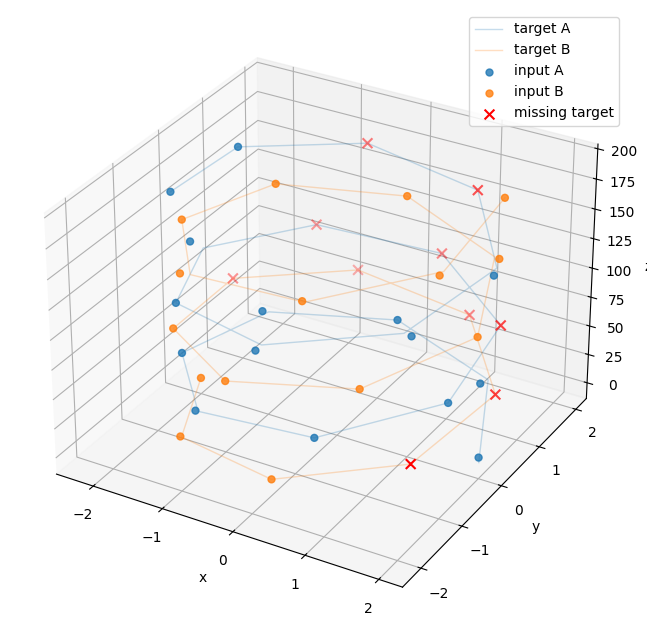

In [40]:
plot_degraded_helix_3d(
    input_points=input_points,
    target_points=target_points,
    missing_points=missing_points,
)

In [41]:
def build_training_schema():
    return{
        "node_input_columns": [
            "x_obs",
            "y_obs",
            "z_obs",
        ],
        "node_target_columns": [
            "x_clean",
            "y_clean",
            "z_clean",
        ],
        "completion_target_columns": [
            "x_clean",
            "y_clean",
            "z_clean",
        ],
        "segment_target_columns": [
            "target_local_rise",
            "target_local_twist_deg",
            "target_point_distance_3d",
            "target_backbone_curvature_approx",
        ],
        "strand_target_columns": [
            "target_global_rise",
            "target_global_twist_deg",
            "target_global_pitch",
            "target_global_n_turns",
        ],
        "metadata_columns": [
            "point_id",
            "strand",
            "point_index",
            "is_observed",
            "is_missing",
            "is_noisy",
        ],
    }

def validate_training_sample(
        input_points,
        target_points,
        missing_points,
        target_segments,
        strand_metadata,
        training_schema,
):
    results = {}

    results["target_point_ids_unique"] = target_points["point_id"].is_unique
    results["input_point_ids_unique"] = input_points["point_id"].is_unique
    results["missing_point_ids_unique"] = missing_points["point_id"].is_unique

    input_ids = set(input_points["point_id"])
    missing_ids = set(missing_points["point_id"])
    target_ids = set(target_points["point_id"])

    results["input_and_missing_disjoint"] = input_ids.isdisjoint(missing_ids)
    results["input_plus_missing_equals_target"] = (input_ids | missing_ids) == target_ids

    results["input_has_no_missing_points"] = not input_points["is_missing"].any()
    results["missing_has_no_observed_points"] = not missing_points["is_observed"].any()

    results["input_node_columns_exist"] = all(
        column in input_points.columns
        for column in training_schema["node_input_columns"]
    )

    results["target_node_columns_exist"] = all(
        column in target_points.columns
        for column in training_schema["node_target_columns"]
    )

    results["segment_target_columns_exist"] = all(
        column in target_segments.columns
        for column in training_schema["segment_target_columns"]
    )

    results["strand_target_columns_exist"] = all(
        column in strand_metadata.columns
        for column in training_schema["strand_target_columns"]
    )

    results["input_node_columns_are_finite"] = np.isfinite(
        input_points[training_schema["node_input_columns"]].to_numpy()
    ).all()

    results["target_node_columns_are_finite"] = np.isfinite(
        target_segments[training_schema["segment_target_columns"]].to_numpy()
    ).all()

    results["segment_targets_are_finite"] = np.isfinite(
        target_segments[training_schema["segment_target_columns"]].to_numpy()
    ).all()

    validation = pd.Series(results)

    if not validation.all():
        failed_checks = validation[~validation].index.tolist()
        raise ValueError(f"Training sample validation failed: {failed_checks}")
    
    return validation




In [42]:
training_schema = build_training_schema()
training_schema

{'node_input_columns': ['x_obs', 'y_obs', 'z_obs'],
 'node_target_columns': ['x_clean', 'y_clean', 'z_clean'],
 'completion_target_columns': ['x_clean', 'y_clean', 'z_clean'],
 'segment_target_columns': ['target_local_rise',
  'target_local_twist_deg',
  'target_point_distance_3d',
  'target_backbone_curvature_approx'],
 'strand_target_columns': ['target_global_rise',
  'target_global_twist_deg',
  'target_global_pitch',
  'target_global_n_turns'],
 'metadata_columns': ['point_id',
  'strand',
  'point_index',
  'is_observed',
  'is_missing',
  'is_noisy']}

In [43]:
strand_metadata


,strand,phase_deg,target_global_rise,target_global_twist_deg,target_global_pitch,target_global_n_turns,n_points,n_observed,n_missing,n_noisy,missing_fraction_actual,noise_fraction_actual,radius_mean,radius_min,radius_max
0,A,0.0,10,48.8,73.770492,2.575556,20,15,5,12,0.25,0.6,2.0,2.0,2.0
1,B,180.0,10,48.8,73.770492,2.575556,20,15,5,8,0.25,0.4,2.0,2.0,2.0


In [44]:
validation = validate_training_sample(
    input_points=input_points,
    target_points=target_points,
    missing_points=missing_points,
    target_segments=target_segments,
    strand_metadata=strand_metadata,
    training_schema=training_schema,
)

validation

target_point_ids_unique             True
input_point_ids_unique              True
missing_point_ids_unique            True
input_and_missing_disjoint          True
input_plus_missing_equals_target    True
input_has_no_missing_points         True
missing_has_no_observed_points      True
input_node_columns_exist            True
target_node_columns_exist           True
segment_target_columns_exist        True
strand_target_columns_exist         True
input_node_columns_are_finite       True
target_node_columns_are_finite      True
segment_targets_are_finite          True
dtype: bool

In [45]:
input_points[training_schema["node_input_columns"]]

,x_obs,y_obs,z_obs
0,1.943606,1.002751e-01,-0.146695
1,1.274419,1.376845e+00,9.999853
2,-0.264513,1.982431e+00,20.000000
3,-1.748150,1.086001e+00,29.808836
4,-1.930033,-5.243784e-01,40.000000
5,-0.910806,-1.800991e+00,50.021588
6,0.775031,-1.843726e+00,60.000000
7,1.897752,-6.312981e-01,70.000000
11,-2.230626,1.737998e-01,109.901073
12,-1.399327,-1.428945e+00,120.000000


In [46]:
input_points

,strand,point_index,x,y,z,center_x,center_y,center_z,tx,ty,...,y_obs,z_obs,noise_dx,noise_dy,noise_dz,noise_norm,is_noisy,is_missing,is_observed,point_id
0,A,0,2.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,1.002751e-01,-0.146695,-0.056394,0.100275,-0.146695,0.186427,True,False,True,A_0
1,A,1,1.317379,1.504830e+00,10.0,0.0,0.0,10.0,0.0,0.0,...,1.376845e+00,9.999853,-0.042960,-0.127985,-0.000147,0.135002,True,False,True,A_1
2,A,2,-0.264513,1.982431e+00,20.0,0.0,0.0,20.0,0.0,0.0,...,1.982431e+00,20.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_2
3,A,3,-1.665842,1.106783e+00,30.0,0.0,0.0,30.0,0.0,0.0,...,1.086001e+00,29.808836,-0.082308,-0.020782,-0.191164,0.209166,True,False,True,A_3
4,A,4,-1.930033,-5.243784e-01,40.0,0.0,0.0,40.0,0.0,0.0,...,-5.243784e-01,40.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_4
5,A,5,-0.876742,-1.797588e+00,50.0,0.0,0.0,50.0,0.0,0.0,...,-1.800991e+00,50.021588,-0.034064,-0.003403,0.021588,0.040472,True,False,True,A_5
6,A,6,0.775031,-1.843726e+00,60.0,0.0,0.0,60.0,0.0,0.0,...,-1.843726e+00,60.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_6
7,A,7,1.897752,-6.312981e-01,70.0,0.0,0.0,70.0,0.0,0.0,...,-6.312981e-01,70.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_7
11,A,11,-1.996882,1.116430e-01,110.0,0.0,0.0,110.0,0.0,0.0,...,1.737998e-01,109.901073,-0.233744,0.062157,-0.098927,0.261317,True,False,True,A_11
12,A,12,-1.399327,-1.428945e+00,120.0,0.0,0.0,120.0,0.0,0.0,...,-1.428945e+00,120.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_12


# Graph generation

In [47]:
@dataclass
class GraphConfig:
    method: str = "knn"
    k_neighbors: int = 6
    force_gap_edges: bool = True



def build_gap_table(target_points):
    rows = []

    for strand_name, strand_points in target_points.groupby("strand"):
        strand_points = strand_points.sort_values("point_index").reset_index(drop=True)

        is_missing = strand_points["is_missing"].to_numpy()
        point_indices = strand_points["point_index"].to_numpy()
        point_ids = strand_points["point_id"].to_numpy()

        i = 0

        while i < len(strand_points):
            if not is_missing[i]:
                i += 1
                continue

            gap_start_pos = i

            while i < len(strand_points) and is_missing[i]:
                i += 1

            gap_end_pos = i - 1

            left_pos = gap_start_pos -1
            right_pos = gap_end_pos + 1

            has_left = left_pos >= 0 and not is_missing[left_pos]
            has_right = right_pos < len(strand_points) and not is_missing[right_pos]

            if has_left and has_right:
                rows.append({
                    "strand": strand_name,
                    "gap_start_point_id": point_ids[left_pos],
                    "gap_end_point_id": point_ids[right_pos],
                    "gap_start_index": int(point_indices[left_pos]),
                    "gap_end_index": int(point_indices[right_pos]),
                    "first_missing_index": int(point_indices[gap_start_pos]),
                    "last_missing_index": int(point_indices[gap_end_pos]),
                    "gap_size": int(gap_end_pos - gap_start_pos + 1),
                    "missing_point_ids": list(point_ids[gap_start_pos:gap_end_pos + 1]),
                })

    return pd.DataFrame(rows)

def build_gap_edge_lookup(gap_table):
    gap_lookup = {}

    for _, gap in gap_table.iterrows():
        start_id = gap["gap_start_point_id"]
        end_id = gap["gap_end_point_id"]

        gap_lookup[(start_id, end_id)] = gap.to_dict()
        gap_lookup[(end_id, start_id)] = gap.to_dict()

    return gap_lookup

def classify_observed_edge(source, target, gap_lookup):
    source_id = source["point_id"]
    target_id = target["point_id"]

    if (source_id, target_id) in gap_lookup:
        return "gap_connection"
    
    same_strand = source["strand"] == target["strand"]

    if same_strand:
        index_gap = abs(int(target["point_index"]) - int(source["point_index"]))

        if index_gap == 1:
            return "target_consecutive_observed"
        
    return "other_connection"

def build_observed_edge(source_node, target_node, nodes, node_features, gap_lookup, edge_source):
    source = nodes.iloc[source_node]
    target = nodes.iloc[target_node]

    source_position = node_features[source_node]
    target_position = node_features[target_node]

    delta = target_position - source_position
    distance = np.linalg.norm(delta)

    edge_type = classify_observed_edge(
        source = source,
        target = target,
        gap_lookup = gap_lookup,
    )

    return {
        "source_node": int(source_node),
        "target_node": int(target_node),
        "source_point_id": source["point_id"],
        "target_point_id": target["point_id"],
        "source_strand": source["strand"],
        "target_strand": target["strand"],
        "source_point_index": int(source["point_index"]),
        "target_point_index": int(target["point_index"]),
        "distance": float(distance),
        "dx": float(delta[0]),
        "dy": float(delta[1]),
        "dz": float(delta[2]),
        "edge_type": edge_type,
        "edge_source": edge_source,
    }


def get_forced_gap_node_pairs(gap_table, nodes):
    point_id_to_node = {
        point_id: node_index
        for node_index, point_id in enumerate(nodes["point_id"])
    }

    forced_pairs = set()

    for _, gap in gap_table.iterrows():
        start_id = gap["gap_start_point_id"]
        end_id = gap["gap_end_point_id"]

        if start_id not in point_id_to_node or end_id not in point_id_to_node:
            continue

        i = point_id_to_node[start_id]
        j = point_id_to_node[end_id]

        if i != j:
            forced_pairs.add((min(i, j), max(i, j)))

    return forced_pairs


def build_observed_knn_graph(input_points, target_points, graph_config, training_schema):
    node_features = input_points[training_schema["node_input_columns"]].to_numpy()

    tree = cKDTree(node_features)

    distances, neighbor_indices = tree.query(
        node_features,
        k=graph_config.k_neighbors + 1,
    )

    gap_table = build_gap_table(target_points)
    gap_lookup = build_gap_edge_lookup(gap_table)

    nodes = input_points.reset_index(drop=True).copy()
    undirected_pairs = set()

    for source_node in range(len(input_points)):
        for neighbor_position in range(1, graph_config.k_neighbors + 1):
            target_node = neighbor_indices[source_node, neighbor_position]

            i = min(source_node, target_node)
            j = max(source_node, target_node)

            if i != j:
                undirected_pairs.add((i, j))

    knn_pairs = set(undirected_pairs)    

    if graph_config.force_gap_edges:
        forced_gap_pairs = get_forced_gap_node_pairs(
            gap_table = gap_table,
            nodes = nodes,
        )

        undirected_pairs |= forced_gap_pairs

    else:
        forced_gap_pairs = set()

    
    point_ids = input_points["point_id"].to_numpy()

    edges = []

    for i, j in sorted(undirected_pairs):

        if (i, j) in forced_gap_pairs and (i, j) not in knn_pairs:
            edge_source = "forced_gap"
        elif (i, j) in forced_gap_pairs and (i, j) in knn_pairs:
            edge_source = "knn_and_gap"
        else:
            edge_source = "knn"

        edge_ij = build_observed_edge(
            source_node = i,
            target_node = j,
            nodes = nodes,
            node_features = node_features,
            gap_lookup = gap_lookup,
            edge_source = edge_source,
        )

        edge_ji = build_observed_edge(
            source_node=j,
            target_node=i,
            nodes=nodes,
            node_features=node_features,
            gap_lookup=gap_lookup,
            edge_source = edge_source,
        )

        edges.append(edge_ij)
        edges.append(edge_ji)

    edges = pd.DataFrame(edges)
            
    edge_index = edges[["source_node", "target_node"]].to_numpy(dtype=int).T

    edge_features = edges[["distance", "dx", "dy", "dz"]].to_numpy(dtype=float)

    edge_source = "forced_gap" if (i, j) in forced_gap_pairs and (i, j) not in knn_pairs else "knn"


    graph = {
        "node_features": node_features,
        "edge_index": edge_index,
        "edge_features": edge_features,
        "nodes": nodes,
        "edges": edges,
        "gap_table": gap_table,
    }

    return graph

def validate_observed_graph(graph):
    node_features = graph["node_features"]
    edge_index = graph["edge_index"]
    edge_features = graph["edge_features"]

    assert node_features.ndim == 2
    assert edge_index.shape[0] == 2
    assert edge_index.shape[1] == edge_features.shape[0]
    assert np.isfinite(node_features).all()
    assert np.isfinite(edge_features).all()
    assert edge_index.min() >= 0
    assert edge_index.max() < len(node_features)

    return {
        "n_nodes": len(node_features),
        "n_edges": edge_index.shape[1],
        "n_edge_features": edge_features.shape[1],
        "graph_is_valid": True,
    }

def validate_undirected_edges(graph):
    edges = graph["edges"]

    directed_pairs = set(
        zip(edges["source_node"], edges["target_node"])
    )

    for source_node, target_node in directed_pairs:
        if (target_node, source_node) not in directed_pairs:
            raise ValueError(
                f"Missing reverse edge for {source_node} -> {target_node}"
            )
        
    return {
        "n_directed_edges": len(edges),
        "n_undirected_edges": len(edges) //2,
        "is_undirected": True,
    }

In [48]:
graph_config = GraphConfig(
    method="knn",
    k_neighbors=6,
    force_gap_edges=True
)

observed_graph = build_observed_knn_graph(
    input_points=input_points,
    target_points=target_points,
    graph_config=graph_config,
    training_schema=training_schema,
)

validate_undirected_edges(observed_graph)

{'n_directed_edges': 212, 'n_undirected_edges': 106, 'is_undirected': True}

In [49]:
observed_graph["edges"]

,source_node,target_node,source_point_id,target_point_id,source_strand,target_strand,source_point_index,target_point_index,distance,dx,dy,dz,edge_type,edge_source
0,0,1,A_0,A_1,A,A,0,1,10.248409,-0.669187,1.276570,10.146548,target_consecutive_observed,knn
1,1,0,A_1,A_0,A,A,1,0,10.248409,0.669187,-1.276570,-10.146548,target_consecutive_observed,knn
2,0,2,A_0,A_2,A,A,0,2,20.354548,-2.208119,1.882156,20.146695,other_connection,knn
3,2,0,A_2,A_0,A,A,2,0,20.354548,2.208119,-1.882156,-20.146695,other_connection,knn
4,0,3,A_0,A_3,A,A,0,3,30.198254,-3.691756,0.985726,29.955531,other_connection,knn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,28,27,B_18,B_17,B,B,18,17,10.032333,-1.225889,-1.038327,-9.902867,target_consecutive_observed,knn
208,27,29,B_17,B_19,B,B,17,19,20.288083,1.143771,2.789437,20.062830,other_connection,knn
209,29,27,B_19,B_17,B,B,19,17,20.288083,-1.143771,-2.789437,-20.062830,other_connection,knn
210,28,29,B_18,B_19,B,B,18,19,10.310091,-0.082117,1.751110,10.159963,target_consecutive_observed,knn


# Target graph

In [50]:
@dataclass
class TargetGraphConfig:
    include_true_edges: bool = True
    include_gap_edges: bool = True
    include_knn_edges: bool = True
    knn_neighbors: int = 6

def _value(row, clean_name, fallback_name = None):
    if clean_name in row:
        return row[clean_name]

    if fallback_name is not None and fallback_name in row:
        return row[fallback_name]
    
    return np.nan

def build_target_nodes(target_points):
    nodes = target_points.reset_index(drop=True).copy()
    nodes["target_node"] = np.arange(len(nodes))

    return nodes

def build_gap_table_from_target_points(target_points):
    rows = []

    for strand_name, strand_points in target_points.groupby("strand"):
        strand_points = strand_points.sort_values("point_index").reset_index(drop=True)

        is_missing = strand_points["is_missing"].to_numpy()
        point_ids = strand_points["point_id"].to_numpy()
        point_indices = strand_points["point_index"].to_numpy()

        i = 0

        while i < len(strand_points):
            if not is_missing[i]:
                i += 1
                continue

            first_missing_pos = i

            while i < len(strand_points) and is_missing[i]:
                i += 1

            last_missing_pos = i - 1

            left_pos = first_missing_pos - 1
            right_pos = last_missing_pos + 1

            has_left = left_pos >= 0 and not is_missing[left_pos]
            has_right = right_pos < len(strand_points) and not is_missing[right_pos]

            if has_left and has_right:
                rows.append({
                    "strand": strand_name,
                    "gap_start_point_id": point_ids[left_pos],
                    "gap_end_point_id": point_ids[right_pos],
                    "gap_start_index": int(point_indices[left_pos]),
                    "gap_end_index": int(point_indices[right_pos]),
                    "first_missing_index": int(point_indices[first_missing_pos]),
                    "last_missing_index": int(point_indices[last_missing_pos]),
                    "gap_size": int(last_missing_pos - first_missing_pos + 1),
                    "missing_point_ids": list(point_ids[first_missing_pos:last_missing_pos + 1]),
                })

    return pd.DataFrame(rows)

def make_directed_edge(source_node, target_node, nodes, edge_type, edge_source, extra = None):
    source = nodes.iloc[source_node]
    target = nodes.iloc[target_node]

    source_position = source[["x_clean", "y_clean", "z_clean"]].to_numpy(dtype=float)
    target_position = target[["x_clean", "y_clean", "z_clean"]].to_numpy(dtype=float)

    delta = target_position - source_position
    distance = np.linalg.norm(delta)

    row = {
        "source_node": int(source_node),
        "target_node": int(target_node),
        "source_point_id": source["point_id"],
        "target_point_id": target["point_id"],
        "source_strand": source["strand"],
        "target_strand": target["strand"],
        "source_point_index": int(source["point_index"]),
        "target_point_index": int(target["point_index"]),
        "edge_type": edge_type,
        "edge_source": edge_source,
        "distance": float(distance),
        "dx": float(delta[0]),
        "dy": float(delta[1]),
        "dz": float(delta[2]),
    }

    if extra is not None:
        row.update(extra)

    return row

def add_true_filament_edges(rows, nodes, target_segments, point_id_to_node):
    for _, segment in target_segments.iterrows():
        source_id = segment["point_id_i"]
        target_id = segment["point_id_j"]

        source_node = point_id_to_node[source_id]
        target_node = point_id_to_node[target_id]

        source_is_missing = not bool(segment["is_i_observed"])
        target_is_missing = not bool(segment["is_j_observed"])

        extra_forward = {
            "target_local_rise": _value(segment, "target_local_rise", "local_rise"),
            "target_local_twist_deg": _value(segment, "target_local_twist_deg", "local_twist_deg"),
            "target_point_distance_3d": _value(segment, "target_point_distance_3d", "point_distance_3d"),
            "target_backbone_curvature_approx": _value(
                segment,
                "target_backbone_curvature_approx",
                "backbone_curvature_approx",
            ),
            "source_is_missing": source_is_missing,
            "target_is_missing": target_is_missing,
            "edge_has_missing": source_is_missing or target_is_missing,
            "use_for_local_structure_loss": True,
        }

        extra_reverse = extra_forward.copy()
        extra_reverse["target_local_twist_deg"] = -extra_reverse["target_local_twist_deg"]

        rows.append(make_directed_edge(
            source_node,
            target_node,
            nodes,
            edge_type="true_filament_edge",
            edge_source="target_segments",
            extra=extra_forward,
        ))

        rows.append(make_directed_edge(
            target_node,
            source_node,
            nodes,
            edge_type="true_filament_edge",
            edge_source="target_segments",
            extra=extra_reverse,
        ))

def add_gap_boundary_edges(rows, nodes, gap_table, point_id_to_node):
    existing_pairs = {
        (row["source_point_id"], row["target_point_id"])
        for row in rows
    }

    for _, gap in gap_table.iterrows():
        source_id = gap["gap_start_point_id"]
        target_id = gap["gap_end_point_id"]

        if source_id not in point_id_to_node or target_id not in point_id_to_node:
            continue

        source_node = point_id_to_node[source_id]
        target_node = point_id_to_node[target_id]

        extra = {
            "gap_size": int(gap["gap_size"]),
            "missing_point_ids": gap["missing_point_ids"],
            "use_for_gap_loss": True,
            "use_for_local_structure_loss": False,
        }

        if (source_id, target_id) not in existing_pairs:
            rows.append(make_directed_edge(
                source_node,
                target_node,
                nodes,
                edge_type="gap_boundary_edge",
                edge_source="gap_table",
                extra=extra,
            ))

        if (target_id, source_id) not in existing_pairs:
            rows.append(make_directed_edge(
                target_node,
                source_node,
                nodes,
                edge_type="gap_boundary_edge",
                edge_source="gap_table",
                extra=extra,
            ))

def add_target_knn_edges(rows, nodes, k_neighbors):
    coordinates = nodes[["x_clean", "y_clean", "z_clean"]].to_numpy(dtype=float)
    tree = cKDTree(coordinates)

    distances, neighbor_indices = tree.query(
        coordinates,
        k = k_neighbors + 1,
    )

    existing_undirected = {
        tuple(sorted((row["source_point_id"], row["target_point_id"])))
        for row in rows
    }

    for source_node in range(len(nodes)):
        for neighbor_position in range(1, k_neighbors + 1):
            target_node = int(neighbor_indices[source_node, neighbor_position])

            if source_node == target_node:
                continue

            pair = tuple(sorted((source_node, target_node)))

            if pair in existing_undirected:
                continue

            existing_undirected.add(pair)

            rows.append(make_directed_edge(
                source_node,
                target_node,
                nodes,
                edge_type="target_knn_edge",
                edge_source="target_knn",
                extra={
                    "use_for_gap_loss": False,
                    "use_for_local_structure_loss": False,
                },
            ))

            rows.append(make_directed_edge(
                target_node,
                source_node,
                nodes,
                edge_type="target_knn_edge",
                edge_source="target_knn",
                extra={
                    "use_for_gap_loss": False,
                    "use_for_local_structure_loss": False,
                },
            ))

def build_completed_target_graph(
        target_points,
        target_segments,
        config=TargetGraphConfig(),
):
    nodes = build_target_nodes(target_points)

    point_id_to_node = {
        point_id: node_index
        for node_index, point_id in enumerate(nodes["point_id"])
    }

    gap_table = build_gap_table_from_target_points(target_points)
    rows = []

    if config.include_true_edges:
        add_true_filament_edges(
            rows = rows,
            nodes = nodes,
            target_segments = target_segments,
            point_id_to_node = point_id_to_node,
        )

    if config.include_gap_edges:
        add_gap_boundary_edges(
            rows=rows,
            nodes=nodes,
            gap_table=gap_table,
            point_id_to_node=point_id_to_node,
        )

    if config.include_knn_edges:
        add_target_knn_edges(
            rows=rows,
            nodes=nodes,
            k_neighbors=config.knn_neighbors,
        )

    edges = pd.DataFrame(rows)

    node_features = nodes[["x_clean", "y_clean", "z_clean"]].to_numpy(dtype=float)
    edge_index = edges[["source_node", "target_node"]].to_numpy(dtype=int).T
    edge_features = edges[["distance", "dx", "dy", "dz"]].to_numpy(dtype=float)

    completed_target_graph = {
        "node_features": node_features,
        "edge_index": edge_index,
        "edge_features": edge_features,
        "nodes": nodes,
        "edges": edges,
        "gap_table": gap_table,
    }

    return completed_target_graph


In [51]:
target_points

,strand,point_index,x,y,z,center_x,center_y,center_z,tx,ty,...,y_obs,z_obs,noise_dx,noise_dy,noise_dz,noise_norm,is_noisy,is_missing,is_observed,point_id
0,A,0,2.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,...,1.002751e-01,-0.146695,-0.056394,0.100275,-0.146695,0.186427,True,False,True,A_0
1,A,1,1.317379,1.504830e+00,10.0,0.0,0.0,10.0,0.0,0.0,...,1.376845e+00,9.999853,-0.042960,-0.127985,-0.000147,0.135002,True,False,True,A_1
2,A,2,-0.264513,1.982431e+00,20.0,0.0,0.0,20.0,0.0,0.0,...,1.982431e+00,20.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_2
3,A,3,-1.665842,1.106783e+00,30.0,0.0,0.0,30.0,0.0,0.0,...,1.086001e+00,29.808836,-0.082308,-0.020782,-0.191164,0.209166,True,False,True,A_3
4,A,4,-1.930033,-5.243784e-01,40.0,0.0,0.0,40.0,0.0,0.0,...,-5.243784e-01,40.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_4
5,A,5,-0.876742,-1.797588e+00,50.0,0.0,0.0,50.0,0.0,0.0,...,-1.800991e+00,50.021588,-0.034064,-0.003403,0.021588,0.040472,True,False,True,A_5
6,A,6,0.775031,-1.843726e+00,60.0,0.0,0.0,60.0,0.0,0.0,...,-1.843726e+00,60.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_6
7,A,7,1.897752,-6.312981e-01,70.0,0.0,0.0,70.0,0.0,0.0,...,-6.312981e-01,70.000000,0.000000,0.000000,0.000000,0.000000,False,False,True,A_7
8,A,8,1.725027,1.012068e+00,80.0,0.0,0.0,80.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,A_8
9,A,9,0.374763,1.964575e+00,90.0,0.0,0.0,90.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False,A_9


In [52]:
gap_table = build_completed_target_graph(
    target_points=target_points,
    target_segments=target_segments,
    config=target_graph_config,
)
gap_table["edges"]

NameError: name 'target_graph_config' is not defined

In [53]:
gap_table

NameError: name 'gap_table' is not defined

In [54]:
target_segments

,strand,point_id_i,point_id_j,point_index_i,point_index_j,target_local_rise,target_local_twist_deg,target_local_twist_rad,target_center_distance,target_point_distance_3d,target_local_radius_i,target_local_radius_j,target_backbone_tangent_angle_deg,target_backbone_curvature_approx,is_i_observed,is_j_observed,segment_is_observed,segment_has_missing
0,A,A_0,A_1,0,1,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,True,True,True,False
1,A,A_1,A_2,1,2,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,True,True,True,False
2,A,A_2,A_3,2,3,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,True,True,True,False
3,A,A_3,A_4,3,4,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,True,True,True,False
4,A,A_4,A_5,4,5,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,True,True,True,False
5,A,A_5,A_6,5,6,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,True,True,True,False
6,A,A_6,A_7,6,7,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,True,True,True,False
7,A,A_7,A_8,7,8,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,True,False,False,True
8,A,A_8,A_9,8,9,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,False,False,False,True
9,A,A_9,A_10,9,10,10.0,48.8,0.851721,10.0,10.135605,2.0,2.0,0.0,0.0,False,False,False,True


In [55]:
target_graph_config = TargetGraphConfig(
    include_true_edges=True,
    include_gap_edges=True,
    include_knn_edges=True,
    knn_neighbors=6,
)

completed_target_graph = build_completed_target_graph(
    target_points=target_points,
    target_segments=target_segments,
    config=target_graph_config,
)

In [56]:
completed_target_graph["edges"]


,source_node,target_node,source_point_id,target_point_id,source_strand,target_strand,source_point_index,target_point_index,edge_type,edge_source,...,target_local_twist_deg,target_point_distance_3d,target_backbone_curvature_approx,source_is_missing,target_is_missing,edge_has_missing,use_for_local_structure_loss,gap_size,missing_point_ids,use_for_gap_loss
0,0,1,A_0,A_1,A,A,0,1,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
1,1,0,A_1,A_0,A,A,1,0,true_filament_edge,target_segments,...,-48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
2,1,2,A_1,A_2,A,A,1,2,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
3,2,1,A_2,A_1,A,A,2,1,true_filament_edge,target_segments,...,-48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
4,2,3,A_2,A_3,A,A,2,3,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,39,38,B_19,B_18,B,B,19,18,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
334,39,37,B_19,B_17,B,B,19,17,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
335,37,39,B_17,B_19,B,B,17,19,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
336,39,16,B_19,A_16,B,A,19,16,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False


# Visualize graph

In [57]:
def get_unique_undirected_edges(edges):
    edges = edges.copy()

    edges["node_min"] = edges[["source_node", "target_node"]].min(axis = 1)
    edges["node_max"] = edges[["source_node", "target_node"]].max(axis = 1)

    unique_edges = (
        edges
        .drop_duplicates(subset=["node_min", "node_max"])
        .drop(columns=["node_min", "node_max"])
        .reset_index(drop=True)
    )

    return unique_edges

def plot_observed_graph_by_edge_type(observed_graph):
    nodes = observed_graph["nodes"].reset_index(drop=True)
    edges = get_unique_undirected_edges(observed_graph["edges"])

    color_by_type = {
        "gap_connection": "red",
        "target_consecutive_observed": "tab:blue",
        "other_connection": "tab:gray",
    }

    alpha_by_type = {
        "gap_connection": 0.75,
        "target_consecutive_observed": 0.75,
        "other_connection": 0.25,
    }

    linewidth_by_type = {
        "gap_connection": 1.5,
        "target_consecutive_observed": 1.5,
        "other_connection": 0.8,
    }

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection = "3d")

    for _, edge in edges.iterrows():
        source = nodes.iloc[int(edge["source_node"])]
        target = nodes.iloc[int(edge["target_node"])]

        edge_type = edge["edge_type"]

        ax.plot(
            [source["x_obs"], target["x_obs"]],
            [source["y_obs"], target["y_obs"]],
            [source["z_obs"], target["z_obs"]],
            color = color_by_type[edge_type],
            alpha = alpha_by_type[edge_type],
            linewidth = linewidth_by_type[edge_type],
        )

    for strand_name, strand_points in nodes.groupby("strand"):
        ax.scatter(
            strand_points["x_obs"],
            strand_points["y_obs"],
            strand_points["z_obs"],
            s = 25,
            label = f"strand {strand_name}",
        )

    ax.plot([], [], [], color = "red", linewidth = 1.5, label = "gap_connection")
    ax.plot([], [], [], color="tab:blue", linewidth=1.5, label="strand consecutive")
    ax.plot([], [], [], color="tab:gray", linewidth=0.8, label="other connection")

    ax.set_xlabel("x_obs")
    ax.set_ylabel("y_obs")
    ax.set_zlabel("z_obs")
    ax.legend()

    plt.show()

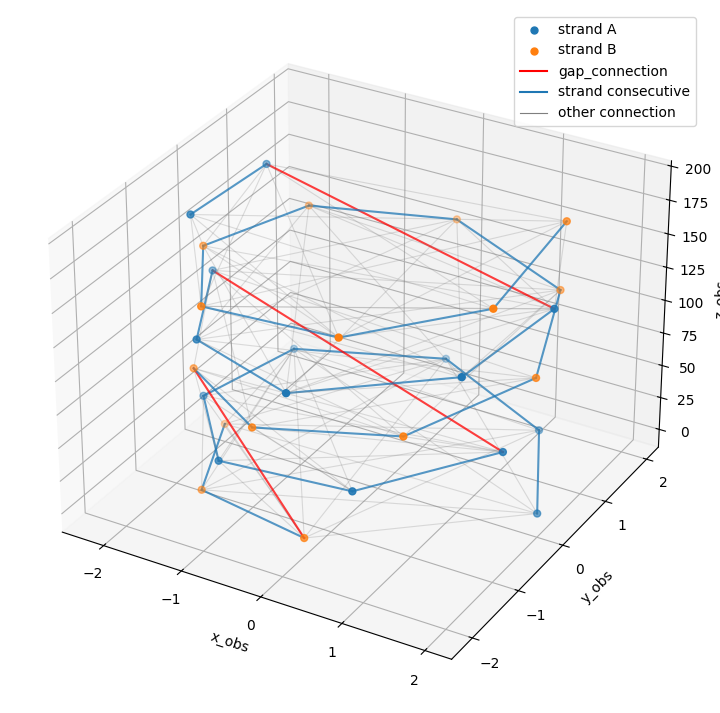

In [58]:
plot_observed_graph_by_edge_type(observed_graph)

In [59]:
def get_unique_graph_edges(edges):
    edges = edges.copy()

    edges["node_min"] = edges[["source_node", "target_node"]].min(axis=1)
    edges["node_max"] = edges[["source_node", "target_node"]].max(axis=1)

    unique_edges = (
        edges
        .drop_duplicates(subset=["node_min", "node_max"])
        .drop(columns=["node_min", "node_max"])
        .reset_index(drop=True)
    )

    return unique_edges

def plot_target_graph_strand_connections(graph):
    nodes = graph["nodes"].reset_index(drop=True)
    edges = get_unique_graph_edges(graph["edges"])

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection="3d")

    for _, edge in edges.iterrows():
        source = nodes.iloc[int(edge["source_node"])]
        target = nodes.iloc[int(edge["target_node"])]
        
        same_strand = source["strand"] == target["strand"]
        filament_connection = edge["edge_type"] == "true_filament_edge"
        gap_connection = edge["edge_type"] == "gap_boundary_edge"

        strand_names = nodes["strand"].unique()
        color_map = plt.get_cmap("tab10")

        strand_colors = {
            strand_name: color_map(i % 10)
            for i, strand_name in enumerate(strand_names)
        }
        color = strand_colors[source["strand"]] if (same_strand and filament_connection) else "tab:gray"
        alpha = 0.75 if (same_strand and (filament_connection or gap_connection)) else 0.25
        linewidth = 1.5 if same_strand else 0.8

        ax.plot(
            [source["x_clean"], target["x_clean"]],
            [source["y_clean"], target["y_clean"]],
            [source["z_clean"], target["z_clean"]],
            color=color,
            alpha=alpha,
            linewidth=linewidth,
        )

    for strand_name, strand_points in nodes.groupby("strand"):
        ax.scatter(
            strand_points["x_clean"],
            strand_points["y_clean"],
            strand_points["z_clean"],
            s=24,
            label=f"strand {strand_name}",
        )

    ax.plot([], [], [], color="tab:blue", linewidth=1.5, label="same strand")
    ax.plot([], [], [], color="tab:gray", linewidth=0.8, label="other connection")

    ax.set_xlabel("x_clean")
    ax.set_ylabel("y_clean")
    ax.set_zlabel("z_clean")
    ax.legend()

    plt.show()

In [60]:
completed_target_graph["edges"]

,source_node,target_node,source_point_id,target_point_id,source_strand,target_strand,source_point_index,target_point_index,edge_type,edge_source,...,target_local_twist_deg,target_point_distance_3d,target_backbone_curvature_approx,source_is_missing,target_is_missing,edge_has_missing,use_for_local_structure_loss,gap_size,missing_point_ids,use_for_gap_loss
0,0,1,A_0,A_1,A,A,0,1,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
1,1,0,A_1,A_0,A,A,1,0,true_filament_edge,target_segments,...,-48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
2,1,2,A_1,A_2,A,A,1,2,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
3,2,1,A_2,A_1,A,A,2,1,true_filament_edge,target_segments,...,-48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
4,2,3,A_2,A_3,A,A,2,3,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,39,38,B_19,B_18,B,B,19,18,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
334,39,37,B_19,B_17,B,B,19,17,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
335,37,39,B_17,B_19,B,B,17,19,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
336,39,16,B_19,A_16,B,A,19,16,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False


In [61]:
completed_target_graph["edges"][completed_target_graph["edges"]["source_point_id"] == "A_0"]

,source_node,target_node,source_point_id,target_point_id,source_strand,target_strand,source_point_index,target_point_index,edge_type,edge_source,...,target_local_twist_deg,target_point_distance_3d,target_backbone_curvature_approx,source_is_missing,target_is_missing,edge_has_missing,use_for_local_structure_loss,gap_size,missing_point_ids,use_for_gap_loss
0,0,1,A_0,A_1,A,A,0,1,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
82,0,20,A_0,B_0,A,B,0,0,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
84,0,1,A_0,A_1,A,A,0,1,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
86,0,21,A_0,B_1,A,B,0,1,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
88,0,22,A_0,B_2,A,B,0,2,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
90,0,2,A_0,A_2,A,A,0,2,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
92,0,23,A_0,B_3,A,B,0,3,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False


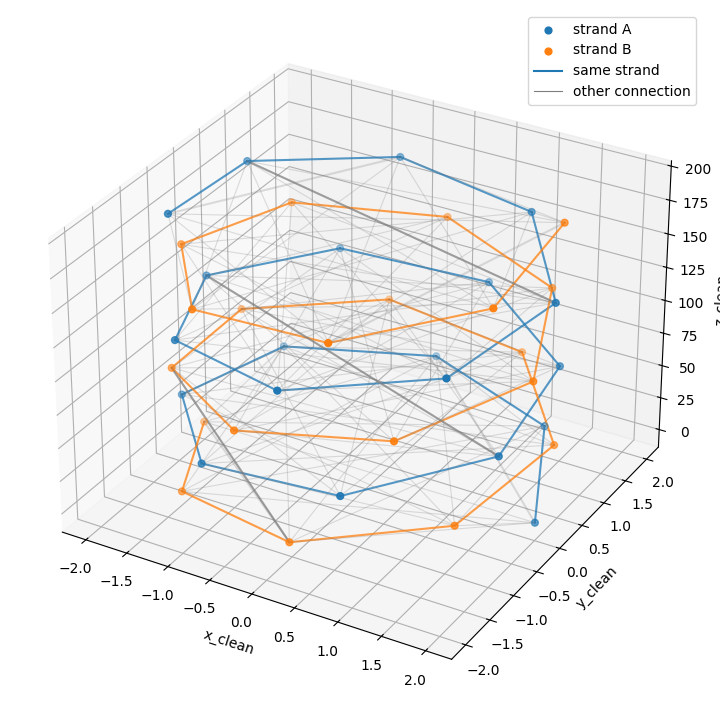

In [62]:
plot_target_graph_strand_connections(completed_target_graph)

In [63]:
completed_target_graph["edges"]

,source_node,target_node,source_point_id,target_point_id,source_strand,target_strand,source_point_index,target_point_index,edge_type,edge_source,...,target_local_twist_deg,target_point_distance_3d,target_backbone_curvature_approx,source_is_missing,target_is_missing,edge_has_missing,use_for_local_structure_loss,gap_size,missing_point_ids,use_for_gap_loss
0,0,1,A_0,A_1,A,A,0,1,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
1,1,0,A_1,A_0,A,A,1,0,true_filament_edge,target_segments,...,-48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
2,1,2,A_1,A_2,A,A,1,2,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
3,2,1,A_2,A_1,A,A,2,1,true_filament_edge,target_segments,...,-48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
4,2,3,A_2,A_3,A,A,2,3,true_filament_edge,target_segments,...,48.8,10.135605,0.0,False,False,False,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,39,38,B_19,B_18,B,B,19,18,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
334,39,37,B_19,B_17,B,B,19,17,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
335,37,39,B_17,B_19,B,B,17,19,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False
336,39,16,B_19,A_16,B,A,19,16,target_knn_edge,target_knn,...,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False


In [64]:
def plot_target_graph_missing_and_gap(graph):
    nodes = graph["nodes"].reset_index(drop=True)
    edges = get_unique_graph_edges(graph["edges"])

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection="3d")

    strand_names = nodes["strand"].unique()
    color_map = plt.get_cmap("tab10")

    strand_colors = {
        strand_name: color_map(i % 10)
        for i, strand_name in enumerate(strand_names)
    }

    for _, edge in edges.iterrows():
        source = nodes.iloc[int(edge["source_node"])]
        target = nodes.iloc[int(edge["target_node"])]

        edge_type = edge["edge_type"]
        value = (edge.get("edge_has_missing", False))
        edge_has_missing = False if pd.isna(value) else bool(value)

        if edge_type == "gap_boundary_edge":
            color = "red"
            alpha = 0.95
            linewidth = 2.8
        elif edge_has_missing == True:
            color = "tab:green"
            alpha = 0.9
            linewidth = 2.2
        elif edge_type == "true_filament_edge":
            color = strand_colors[source["strand"]]
            alpha = 0.5
            linewidth = 1.2
        else:
            color = "tab:gray"
            alpha = 0.22
            linewidth = 0.8

        ax.plot(
            [source["x_clean"], target["x_clean"]],
            [source["y_clean"], target["y_clean"]],
            [source["z_clean"], target["z_clean"]],
            color=color,
            alpha=alpha,
            linewidth=linewidth,
        )

    observed_points = nodes[nodes["is_observed"]]
    missing_points = nodes[nodes["is_missing"]]

    for strand_name, strand_points in observed_points.groupby("strand"):
        ax.scatter(
            strand_points["x_clean"],
            strand_points["y_clean"],
            strand_points["z_clean"],
            s=24,
            label=f"observed {strand_name}",
        )

    if len(missing_points) > 0:
        ax.scatter(
            missing_points["x_clean"],
            missing_points["y_clean"],
            missing_points["z_clean"],
            color="tab:orange",
            marker="x",
            s=60,
            label="missing nodes",
        )

    ax.plot([], [], [], color="red", linewidth=2.8, label="gap boundary")
    ax.plot([], [], [], color="tab:orange", linewidth=2.2, label="missing segment")
    ax.plot([], [], [], color="tab:blue", linewidth=1.2, label="true filament")
    ax.plot([], [], [], color="tab:gray", linewidth=0.8, label="other connection")

    ax.set_xlabel("x_clean")
    ax.set_ylabel("y_clean")
    ax.set_zlabel("z_clean")
    ax.legend()

    plt.show()

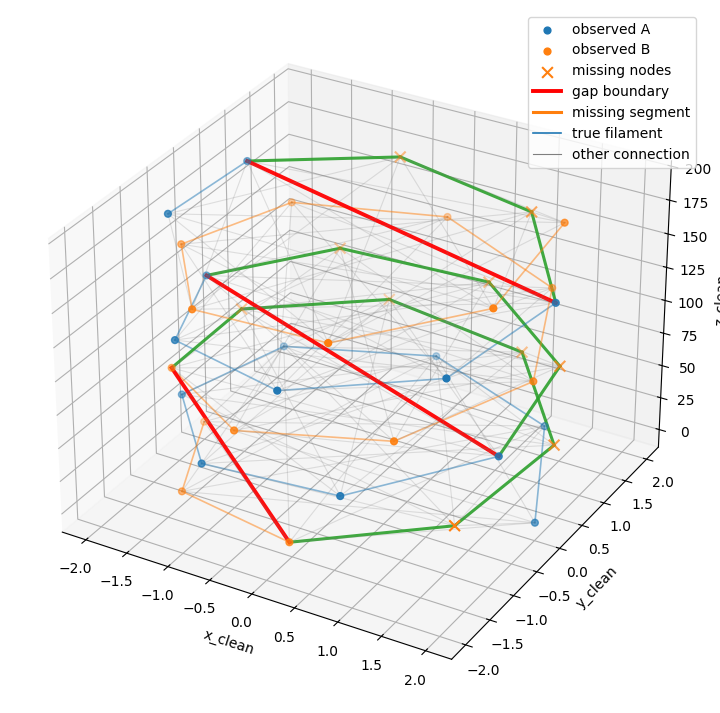

In [65]:
plot_target_graph_missing_and_gap(completed_target_graph)

# Validate

In [66]:
def build_observed_target_node_mapping(observed_graph, completed_target_graph):
    observed_nodes = observed_graph["nodes"].reset_index(drop=True)
    target_nodes = completed_target_graph["nodes"].reset_index(drop=True)

    observed_index_by_point_id = {
        point_id: node_index
        for node_index, point_id in enumerate(observed_nodes["point_id"])
    }

    rows = []

    for target_node_index, target_node in target_nodes.iterrows():
        point_id = target_node["point_id"]
        observed_node_index = observed_index_by_point_id.get(point_id, -1)

        rows.append({
            "point_id": point_id,
            "strand": target_node["strand"],
            "point_index": int(target_node["point_index"]),
            "target_node_index": int(target_node_index),
            "observed_node_index": int(observed_node_index),
            "is_observed": observed_node_index != -1,
            "is_missing": observed_node_index == -1,
        })

    return pd.DataFrame(rows)

In [67]:
def validate_graph_pair(observed_graph, completed_target_graph, node_mapping):
    results= {}

    observed_nodes = observed_graph["nodes"]
    target_nodes = completed_target_graph["nodes"]

    observed_ids = set(observed_nodes["point_id"])
    target_ids = set(target_nodes["point_id"])

    results["observed_ids_subset_of_target"] = observed_ids.issubset(target_ids)
    results["target_point_ids_unique"] = target_nodes["point_id"].is_unique
    results["observed_point_ids_unique"] = observed_nodes["point_id"].is_unique

    results["all_observed_nodes_mapped"] = (
        node_mapping[node_mapping["is_observed"]]["observed_node_index"] >= 0
    ).all()

    results["missing_nodes_not_in_observed_graph"] = (
        node_mapping[node_mapping["is_missing"]]["observed_node_index"] == -1
    ).all()

    results["observed_graph_features_finite"] = np.isfinite(
        observed_graph["node_features"]
    ).all()

    results["target_graph_features_finite"] = np.isfinite(
        completed_target_graph["node_features"]
    ).all()

    results["target_edges_valid"] = (
        completed_target_graph["edge_index"].min() >= 0
        and completed_target_graph["edge_index"].max() < len(target_nodes)
    )

    validation = pd.Series(results)

    if not validation.all():
        failed = validation[~validation].index.tolist()
        raise ValueError(f"Graph pair validation failed: {failed}")

    return validation

In [68]:
training_sample = sample["training_sample"]
observed_graph = training_sample["observed_graph"]
completed_target_graph = training_sample["completed_target_graph"]
node_mapping = training_sample["node_mapping"]
node_mapping

NameError: name 'sample' is not defined

In [ ]:


node_mapping = build_observed_target_node_mapping(
    observed_graph=observed_graph,
    completed_target_graph=completed_target_graph,
)

validation = validate_graph_pair(
    observed_graph=observed_graph,
    completed_target_graph=completed_target_graph,
    node_mapping=node_mapping,
)

validation

observed_ids_subset_of_target          True
target_point_ids_unique                True
observed_point_ids_unique              True
all_observed_nodes_mapped              True
missing_nodes_not_in_observed_graph    True
observed_graph_features_finite         True
target_graph_features_finite           True
target_edges_valid                     True
dtype: bool

# Construct training sample

In [69]:
training_sample = {
    "observed_graph": observed_graph,
    "completed_target_graph": completed_target_graph,
    "node_mapping": node_mapping,
    "strand_metadata": strand_metadata,
}

NameError: name 'node_mapping' is not defined

In [70]:
node_mapping

NameError: name 'node_mapping' is not defined

In [71]:
def training_sample_to_numpy(training_sample):
    observed_graph = training_sample["observed_graph"]
    completed_target_graph = training_sample["completed_target_graph"]
    node_mapping = training_sample["node_mapping"]

    observed_x = observed_graph["node_features"].astype(np.float32)
    observed_edge_index = observed_graph["edge_index"].astype(np.int64)
    observed_edge_attr = observed_graph["edge_features"].astype(np.float32)

    target_x = completed_target_graph["node_features"].astype(np.float32)
    target_edge_index = completed_target_graph["edge_index"].astype(np.int64)
    target_edge_attr = completed_target_graph["edge_features"].astype(np.float32)

    observed_mask = node_mapping["is_observed"].to_numpy(dtype=bool)
    missing_mask = node_mapping["is_missing"].to_numpy(dtype=bool)
    
    observed_to_target = node_mapping["target_node_index"].to_numpy(dtype=np.int64)
    target_to_observed = node_mapping["observed_node_index"].to_numpy(dtype=np.int64)

    tensor_sample = {
        "observed_x": observed_x,
        "observed_edge_index": observed_edge_index,
        "observed_edge_attr": observed_edge_attr,
        "target_x": target_x,
        "target_edge_index": target_edge_index,
        "target_edge_attr": target_edge_attr,
        "observed_mask": observed_mask,
        "missing_mask": missing_mask,
        "observed_to_target": observed_to_target,
        "target_to_observed": target_to_observed,
    }

    return tensor_sample

In [72]:
len(tensor_sample["observed_mask"])

NameError: name 'tensor_sample' is not defined

In [73]:
tensor_sample = training_sample_to_numpy(training_sample)

for key, value in tensor_sample.items():
    print(key, value.shape, value.dtype)

NameError: name 'training_sample' is not defined

In [83]:
def validate_tensor_sample(tensor_sample):
    results = {}

    n_observed_nodes = tensor_sample["observed_x"].shape[0]
    n_target_nodes = tensor_sample["target_x"].shape[0]

    results["observed_x_2d"] = tensor_sample["observed_x"].ndim == 2
    results["target_x_2d"] = tensor_sample["target_x"].ndim == 2
    
    results["observed_edge_index_shape"] = tensor_sample["observed_edge_index"].shape[0] == 2
    results["target_edge_index_shape"] = tensor_sample["target_edge_index"].shape[0] == 2
    
    results["observed_edge_attr_matches_edges"] = (
        tensor_sample["observed_edge_attr"].shape[0]
        == tensor_sample["observed_edge_index"].shape[1]
    )

    results["target_edge_attr_matches_edges"] = (
        tensor_sample["target_edge_attr"].shape[0]
        == tensor_sample["target_edge_index"].shape[1]
    )

    results["masks_match_target_nodes"] = (
        len(tensor_sample["observed_mask"]) == n_target_nodes
        and len(tensor_sample["missing_mask"]) == n_target_nodes
    )

    results["observed_and_missing_disjoint"] = not np.any(
        tensor_sample["observed_mask"] & tensor_sample["missing_mask"]
    )

    results["observed_plus_missing_all_target"] = np.all(
        tensor_sample["observed_mask"] | tensor_sample["missing_mask"]
    )

    results["target_to_observed_length"] = (
        len(tensor_sample["target_to_observed"]) == n_target_nodes
    )

    results["observed_to_target_length"] = (
        len(tensor_sample["observed_to_target"]) == n_target_nodes
    )

    results["observed_features_finite"] = np.isfinite(tensor_sample["observed_x"]).all()
    results["target_features_finite"] = np.isfinite(tensor_sample["target_x"]).all()
    
    validation = pd.Series(results)

    if not validation.all():
        failed = validation[~validation].index.tolist()
        raise ValueError(f"Tensor sample validation failed: {failed}")
    
    return validation

In [ ]:
tensor_sample = sample["tensor_sample"]

In [74]:
validate_tensor_sample(tensor_sample)

NameError: name 'validate_tensor_sample' is not defined

# Generate training sample

In [75]:
def create_strands(n_strands, radius, phase_offset_deg = 0.0, names = None):
    if names is None:
        names = [f"S{i}" for i in range(n_strands)]

    if len(names) != n_strands:
        raise ValueError("names must have the same length as n_strands")
    
    strands = []

    for i, name in enumerate(names):
        strands.append(
            Strand(
                name = name,
                radius = radius,
                phase_deg = phase_offset_deg + i * 360 / n_strands,
            )
        )

    return strands
    
def create_helix_scene(
        backbone_config,
        helix_twist_deg,
        helix_rise,
        n_backbone_points,
        n_strands = 2,
        strand_radius = 2.0,
        strand_names = None,
        radius_variation = None,
):
    backbone = generate_backbone(
        n_points = n_backbone_points,
        config = backbone_config,
    )

    strands = create_strands(
        n_strands = n_strands,
        radius = strand_radius,
        names = strand_names,
    )

    if radius_variation is None:
        radius_variation = RadiusVariationConfig(enabled = False)

    helix = Helix(
        twist_deg = helix_twist_deg,
        rise = helix_rise,
        strands = strands,
        backbone = backbone,
        radius_variation = radius_variation,
    )

    helix_scene = {
        "backbone": backbone,
        "helix": helix,
        "strands": strands,
        "backbone_config": backbone_config,
        "radius_variation": radius_variation,
        "helix_parameters": {
            "twist_deg": helix_twist_deg,
            "rise": helix_rise,
            "n_points": helix.n_points,
            "n_turns": helix. n_turns,
            "pitch": helix.pitch,
            "n_strands": n_strands,
            "strand_radius": strand_radius,
        }
    }

    return helix_scene

In [76]:
def generate_training_sample(
    helix_scene,
    degradation_config,
    graph_config,
    target_graph_config,
    training_schema,
):
    helix = helix_scene["helix"]

    input_points, target_points, missing_points, degradation_info = degrade_helix_points(
        clean_points=helix.points,
        config = degradation_config,
    )

    target_segments = build_target_segments_from_geometry(target_points)

    observed_graph = build_observed_knn_graph(
        input_points = input_points,
        target_points = target_points,
        graph_config = graph_config,
        training_schema = training_schema,
    )

    completed_target_graph = build_completed_target_graph(
        target_points = target_points,
        target_segments = target_segments,
        config = target_graph_config,
    )

    node_mapping = build_observed_target_node_mapping(
        observed_graph = observed_graph,
        completed_target_graph = completed_target_graph,
    )

    training_sample = {
        "helix_scene": helix_scene,
        "input_points": input_points,
        "target_points": target_points,
        "missing_points": missing_points,
        "target_segments": target_segments,
        "observed_graph": observed_graph,
        "completed_target_graph": completed_target_graph,
        "node_mapping": node_mapping,
        "degradation_info": degradation_info,
        "training_schema": training_schema,
    }

    tensor_sample = training_sample_to_numpy(training_sample)

    return training_sample, tensor_sample


In [77]:
backbone_config = BackboneConfig(
    mode = "perturbed",
    seed = 42,
    step_size = 0.5,
    max_angle_deg = 0.8,
    smoothness = 0.8,
    perturbation_probability = 0.5,
)

radius_variation = RadiusVariationConfig(
    enabled = True,
    seed = 123,
    n_control_points = 8,
    min_radius = 1.6,
    max_radius = 2.4,
    smooth_window = 11,
)

helix_scene = create_helix_scene(
    backbone_config = backbone_config,
    helix_twist_deg = 30.0,
    helix_rise = 0.5,
    n_backbone_points = 200,
    n_strands = 2,
    strand_radius = 2.0,
    strand_names = ["A", "B"],
    radius_variation = radius_variation,
)

In [78]:
helix_scene

{'backbone':      points_index  center_x  center_y   center_z
 0               0  0.000000  0.000000   0.000000
 1               1  0.000812  0.000660   0.499999
 2               2  0.001826  0.002632   0.999994
 3               3  0.002375  0.005053   1.499988
 4               4  0.002924  0.007473   1.999982
 ..            ...       ...       ...        ...
 195           195  1.588120  1.559841  97.469473
 196           196  1.604751  1.571751  97.969055
 197           197  1.621382  1.583661  98.468636
 198           198  1.638013  1.595571  98.968218
 199           199  1.653943  1.606705  99.467840
 
 [200 rows x 4 columns],
 'helix': Helix(twist_deg=30.0, rise=0.5, strands=[Strand(name='A', radius=2.0, phase_deg=0.0), Strand(name='B', radius=2.0, phase_deg=180.0)], backbone=     points_index  center_x  center_y   center_z
 0               0  0.000000  0.000000   0.000000
 1               1  0.000812  0.000660   0.499999
 2               2  0.001826  0.002632   0.999994
 3       

In [79]:
training_sample, tensor_sample = generate_training_sample(
    helix_scene=helix_scene,
    degradation_config=degradation_config,
    graph_config=graph_config,
    target_graph_config=target_graph_config,
    training_schema=training_schema,
)


In [80]:
validate_tensor_sample(tensor_sample)

NameError: name 'validate_tensor_sample' is not defined

# Prepare dataset

In [81]:
@dataclass
class Range:
    min: float
    max: float

    def sample(self, rng):
        return rng.uniform(self.min, self.max)

@dataclass
class IntRange:
    min: int
    max: int

    def sample(self, rng):
        return int(rng.integers(self.min, self.max + 1))
    
@dataclass
class DatasetGenerationConfig:
    seed: int = 0
    n_samples: int = 100

    backbone_points: IntRange = IntRange(120,300)
    backbone_step_size: Range = Range(0.3, 0.8)
    backbone_max_angle_deg: Range = Range(2.0, 12.0)
    backbone_smoothness: Range = Range(0.65, 0.96)
    backbone_perturbation_probability: Range = Range(0.5, 0.7)

    twist_deg: Range = Range(15.0, 45.0)
    rise: Range = Range(0.3, 0.8)
    n_strands: IntRange = IntRange(1, 4)
    strand_radius: Range = Range(1.0, 3.0)

    radius_variation_enable_probability: float = 0.7
    radius_min_scale: Range = Range(0.5, 0.7)
    radius_max_scale: Range = Range(1.05, 1.2)
    radius_control_points: IntRange = IntRange(4, 10)
    radius_smooth_window: IntRange = IntRange(5, 15)

    noise_std: Range = Range(0.0, 0.3)
    noise_fraction: Range = Range(0.0, 0.5)
    missing_fraction: Range = Range(0.0, 0.4)
    max_gap_size: IntRange = IntRange(2, 10)

    graph_k_neighbors: IntRange = IntRange(4, 10)

def sample_scene_and_training_configs(dataset_config, sample_seed):
    rng = np.random.default_rng(sample_seed)

    n_backbone_points = dataset_config.backbone_points.sample(rng)
    strand_radius = dataset_config.strand_radius.sample(rng)

    backbone_config = BackboneConfig(
        mode = "perturbed",
        seed = int(rng.integers(0, 1_000_000)),
        step_size = dataset_config.backbone_step_size.sample(rng),
        max_angle_deg = dataset_config.backbone_max_angle_deg.sample(rng),
        smoothness = dataset_config.backbone_smoothness.sample(rng),
        perturbation_probability = dataset_config.backbone_perturbation_probability.sample(rng),
    )

    radius_variation_enabled = (
        rng.random() < dataset_config.radius_variation_enable_probability
    )

    radius_variation = RadiusVariationConfig(
        enabled = radius_variation_enabled,
        seed = int(rng.integers(0, 1_000_000)),
        n_control_points = dataset_config.radius_control_points.sample(rng),
        min_radius = strand_radius * dataset_config.radius_min_scale.sample(rng),
        max_radius = strand_radius * dataset_config.radius_max_scale.sample(rng),
        smooth_window = dataset_config.radius_smooth_window.sample(rng),
    )

    n_strands = dataset_config.n_strands.sample(rng)

    scene_kwargs = {
        "backbone_config": backbone_config,
        "helix_twist_deg": dataset_config.twist_deg.sample(rng),
        "helix_rise": dataset_config.rise.sample(rng),
        "n_backbone_points": n_backbone_points,
        "n_strands": n_strands,
        "strand_radius": strand_radius,
        "strand_names": [f"S{i}" for i in range(n_strands)],
        "radius_variation": radius_variation,        
    }

    degradation_config = DegradationConfig(
        seed = int(rng.integers(0, 1_000_000)),
        noise_std = dataset_config.noise_std.sample(rng),
        noise_fraction = dataset_config.noise_fraction.sample(rng),
        missing_fraction = dataset_config.missing_fraction.sample(rng),
        missing_mode = "segments_per_strand",
        max_gap_size = dataset_config.max_gap_size.sample(rng),
    )

    graph_config = GraphConfig(
        method = "knn",
        k_neighbors = dataset_config.graph_k_neighbors.sample(rng),
        force_gap_edges = True,
    )

    target_graph_config = TargetGraphConfig(
        include_true_edges = True,
        include_gap_edges = True,
        include_knn_edges = True,
        knn_neighbors = 6,
    )

    return scene_kwargs, degradation_config, graph_config, target_graph_config

def generate_dataset(dataset_config, training_schema):
    rng = np.random.default_rng(dataset_config.seed)

    samples = []
    metadata_rows = []

    for sample_index in range(dataset_config.n_samples):
        sample_seed = int(rng.integers(0, 1_000_000))

        scene_kwargs, degradation_config, graph_config, target_graph_config = (
            sample_scene_and_training_configs(
                dataset_config=dataset_config,
                sample_seed=sample_seed,
            )
        )

        helix_scene = create_helix_scene(**scene_kwargs)

        training_sample, tensor_sample = generate_training_sample(
            helix_scene=helix_scene,
            degradation_config=degradation_config,
            graph_config=graph_config,
            target_graph_config=target_graph_config,
            training_schema=training_schema,
        )

        validate_tensor_sample(tensor_sample)

        samples.append({
            "training_sample": training_sample,
            "tensor_sample": tensor_sample,
        })

        metadata_rows.append({
            "sample_index": sample_index,
            "sample_seed": sample_seed,
            "n_observed_nodes": tensor_sample["observed_x"].shape[0],
            "n_target_nodes": tensor_sample["target_x"].shape[0],
            "n_missing_nodes": int(tensor_sample["missing_mask"].sum()),
            "twist_deg": helix_scene["helix_parameters"]["twist_deg"],
            "rise": helix_scene["helix_parameters"]["rise"],
            "pitch": helix_scene["helix_parameters"]["pitch"],
            "n_strands": helix_scene["helix_parameters"]["n_strands"],
            "noise_std": degradation_config.noise_std,
            "noise_fraction": degradation_config.noise_fraction,
            "missing_fraction": degradation_config.missing_fraction,
            "max_gap_size": degradation_config.max_gap_size,
            "k_neighbors": graph_config.k_neighbors,
        })

    dataset_metadata = pd.DataFrame(metadata_rows)

    return samples, dataset_metadata

In [ ]:
dataset_config = DatasetGenerationConfig(
    seed = 123,
    n_samples = 1000,
    backbone_points = IntRange(100,1000),
    backbone_smoothness = Range(0.9, 1),
    backbone_max_angle_deg = Range(0.0, 90.0),
    backbone_perturbation_probability = Range(0.4, 1),
    backbone_step_size = Range(10.0, 29.0),
    rise = Range(0.5,2),
    n_strands = IntRange(1,4),
    radius_smooth_window = IntRange(15,30),
    radius_variation_enable_probability = 0.5,
    radius_control_points = IntRange(10,15),
    radius_min_scale= Range(0.1, 0.2),
    radius_max_scale= Range(3.05, 3.2),
    noise_std = Range(0.0, 0.1),
)

samples, dataset_metadata = generate_dataset(
    dataset_config=dataset_config,
    training_schema=training_schema,
)

In [1451]:
sample = samples[0]

In [1452]:
training_sample = sample["training_sample"]

In [1453]:
training_sample

{'helix_scene': {'backbone':      points_index  center_x  center_y      center_z
  0               0       0.0       0.0      0.000000
  1               1       0.0       0.0     14.673846
  2               2       0.0       0.0     29.347693
  3               3       0.0       0.0     44.021539
  4               4       0.0       0.0     58.695385
  ..            ...       ...       ...           ...
  995           995       0.0       0.0  14600.477110
  996           996       0.0       0.0  14615.150956
  997           997       0.0       0.0  14629.824803
  998           998       0.0       0.0  14644.498649
  999           999       0.0       0.0  14659.172495
  
  [1000 rows x 4 columns],
  'helix': Helix(twist_deg=44.10699608689242, rise=0.6937606434202979, strands=[Strand(name='S0', radius=1.222669171088935, phase_deg=0.0)], backbone=     points_index  center_x  center_y      center_z
  0               0       0.0       0.0      0.000000
  1               1       0.0       0.0

In [1454]:
tensor_sample = sample["tensor_sample"]

In [1455]:
tensor_sample

{'observed_x': array([[ 6.1523509e-01,  0.0000000e+00,  0.0000000e+00],
        [ 4.7142857e-01,  4.5695770e-01,  6.9376063e-01],
        [ 2.1751156e-02,  6.9755894e-01,  1.3875213e+00],
        ...,
        [-4.6615928e-01,  6.8082553e-01,  1.4656388e+04],
        [-6.9214022e-01, -4.0655058e-02,  1.4657037e+04],
        [-6.2472224e-01, -3.9973128e-01,  1.4657774e+04]],
       shape=(16364, 3), dtype=float32),
 'observed_edge_index': array([[    0,     1,     0, ..., 16363, 16362, 16363],
        [    1,     0,     2, ..., 16361, 16363, 16362]], shape=(2, 93066)),
 'observed_edge_attr': array([[ 0.8430863 , -0.14380655,  0.4569577 ,  0.69376063],
        [ 0.8430863 ,  0.14380655, -0.4569577 , -0.69376063],
        [ 1.6625363 , -0.593484  ,  0.69755894,  1.3875213 ],
        ...,
        [ 1.7657747 ,  0.15856296,  1.0805568 , -1.3875213 ],
        [ 0.82336396,  0.06741798, -0.3590762 ,  0.7378667 ],
        [ 0.82336396, -0.06741798,  0.3590762 , -0.7378667 ]],
       shape=(9306

/home/amolina/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


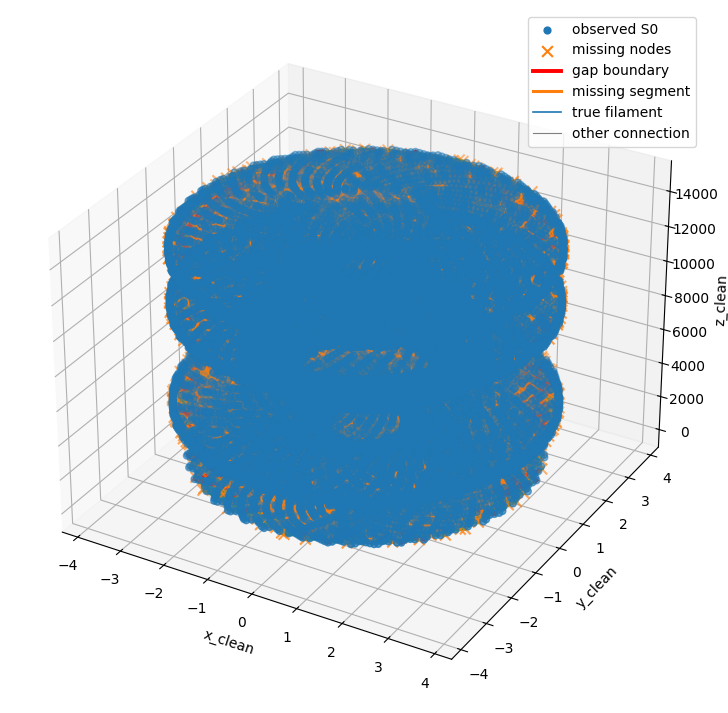

/home/amolina/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


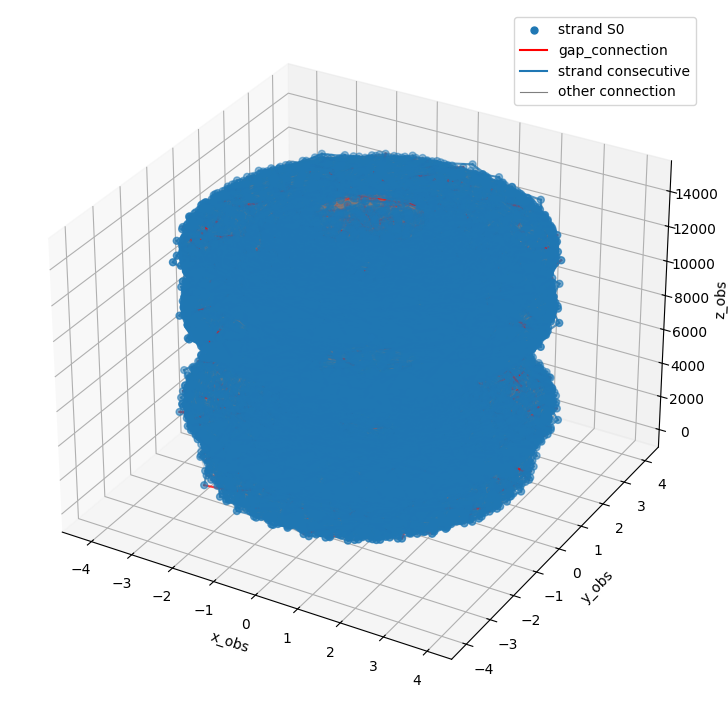

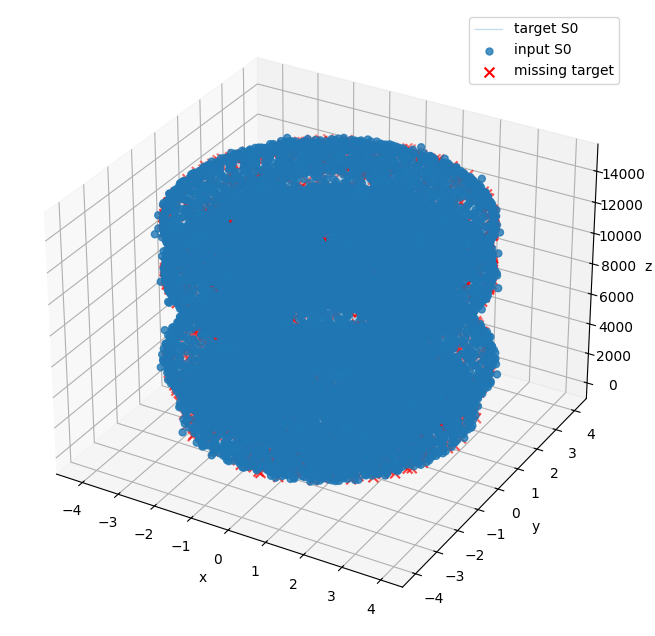

In [1456]:
plot_target_graph_missing_and_gap(training_sample["completed_target_graph"])
plot_observed_graph_by_edge_type(training_sample["observed_graph"])
plot_degraded_helix_3d(
    input_points=training_sample["input_points"],
    target_points=training_sample["target_points"],
    missing_points=training_sample["missing_points"],
)

# Validate dataset

In [1485]:
def validate_generated_dataset(samples, dataset_metadata):
    results = {}

    results["n_samples"] = len(samples)
    results["metadata_matches_samples"] = len(dataset_metadata) == len(samples)

    n_failed = 0
    n_without_missing = 0
    n_tiny_observed_graphs = 0

    for sample in samples:
        tensor_sample = sample["tensor_sample"]
        training_sample = sample["training_sample"]

        try:
            validate_tensor_sample(tensor_sample)

            node_mapping = training_sample["node_mapping"]

            validate_graph_pair(
                observed_graph = training_sample["observed_graph"],
                completed_target_graph = training_sample["completed_target_graph"],
                node_mapping = node_mapping,
            )

        except Exception:
            n_failed += 1

        if tensor_sample["missing_mask"].sum() == 0:
            n_without_missing += 1

        if tensor_sample["observed_x"].shape[0] < 5:
            n_tiny_observed_graphs += 1

    results["n_failed_samples"] = n_failed
    results["n_without_missing"] = n_without_missing
    results["n_tiny_observed_graphs"] = n_tiny_observed_graphs

    results["all_samples_valid"] = n_failed == 0
    results["has_some_missing_samples"] = n_without_missing < len(samples)

    return pd.Series(results)



In [1486]:
dataset_validation = validate_generated_dataset(
    samples=samples,
    dataset_metadata=dataset_metadata,
)

dataset_validation

n_samples                      1
metadata_matches_samples    True
n_failed_samples               0
n_without_missing              0
n_tiny_observed_graphs         0
all_samples_valid           True
has_some_missing_samples    True
dtype: object

In [1490]:
def summarize_generated_dataset(dataset_metadata):
    columns = [
        "n_observed_nodes",
        "n_target_nodes",
        "n_missing_nodes",
        "twist_deg",
        "rise",
        "pitch",
        "n_strands",
        "noise_std",
        "noise_fraction",
        "missing_fraction",
        "max_gap_size",
        "k_neighbors",
    ]

    existing_columns = [
        column for column in columns
        if column in dataset_metadata.columns
    ]

    return dataset_metadata[existing_columns].describe()

In [1491]:
summarize_generated_dataset(dataset_metadata)

,n_observed_nodes,n_target_nodes,n_missing_nodes,twist_deg,rise,pitch,n_strands,noise_std,noise_fraction,missing_fraction,max_gap_size,k_neighbors
count,1.0,1.0,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.00000,1.00000,1.0,1.0
mean,16364.0,21131.0,4767.0,44.106996,0.693761,5.662454,1.0,0.095773,0.39373,0.22557,5.0,5.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,16364.0,21131.0,4767.0,44.106996,0.693761,5.662454,1.0,0.095773,0.39373,0.22557,5.0,5.0
25%,16364.0,21131.0,4767.0,44.106996,0.693761,5.662454,1.0,0.095773,0.39373,0.22557,5.0,5.0
50%,16364.0,21131.0,4767.0,44.106996,0.693761,5.662454,1.0,0.095773,0.39373,0.22557,5.0,5.0
75%,16364.0,21131.0,4767.0,44.106996,0.693761,5.662454,1.0,0.095773,0.39373,0.22557,5.0,5.0
max,16364.0,21131.0,4767.0,44.106996,0.693761,5.662454,1.0,0.095773,0.39373,0.22557,5.0,5.0


# Filter valid samples

In [1501]:
def filter_valid_samples(
        samples,
        dataset_metadata,
        require_missing = True,
        min_observed_nodes = 5,
):
    valid_samples = []
    valid_metadata_rows = []
    rejected_rows = []

    for sample_index, sample in enumerate(samples):
        tensor_sample = sample["tensor_sample"]
        training_sample = sample["training_sample"]

        rejection_reasons = []

        try:
            validate_tensor_sample(tensor_sample)

            validate_graph_pair(
                observed_graph = training_sample["observed_graph"],
                completed_target_graph = training_sample["completed_target_graph"],
                node_mapping = training_sample["node_mapping"],
            )

        except Exception as error:
            rejection_reasons.append(f"validation_failed: {error}")

        n_missing = int(tensor_sample["missing_mask"].sum())
        n_observed = int(tensor_sample["observed_x"].shape[0])

        if require_missing and n_missing == 0:
            rejection_reasons.append("no_missing_nodes")

        if n_observed < min_observed_nodes:
            rejection_reasons.append("too few_observed_nodes")

        if len(rejection_reasons) == 0:
            valid_samples.append(sample)
            valid_metadata_rows.append(dataset_metadata.iloc[sample_index].to_dict())
        else:
            rejected_row = dataset_metadata.iloc[sample_index].to_dict()
            rejected_row["rejection_reasons"] = rejection_reasons
            rejected_rows.append(rejected_row)

    valid_metadata = pd.DataFrame(valid_metadata_rows)
    rejected_metadata = pd.DataFrame(rejected_rows)

    return valid_samples, valid_metadata, rejected_metadata


In [1502]:
valid_samples, valid_metadata, rejected_metadata = filter_valid_samples(
    samples = samples,
    dataset_metadata = dataset_metadata,
    require_missing = True,
    min_observed_nodes = 5,
)

In [1503]:

len(samples), len(valid_samples), len(rejected_metadata)

(1, 1, 0)

In [1499]:
len(samples), len(valid_samples), len(rejected_metadata)

(1, 0, 1)

In [1500]:
rejected_metadata["rejection_reasons"].value_counts()

rejection_reasons
[validation_failed: validate_graph_pair() got an unexpected keyword argument 'completed_target_gragh']    1
Name: count, dtype: int64

# Split dataset

In [1504]:
def split_dataset(samples, dataset_metadata, train_fraction = 0.7, val_fraction = 0.15, seed = 0):
    if len(samples) != len(dataset_metadata):
        raise ValueError("samples and dataset_metadata must have the same length")
    
    rng = np.random.default_rng(seed)

    n_samples = len(samples)
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    n_train = int(round(train_fraction * n_samples))
    n_val = int(round(val_fraction * n_samples))

    train_indices = indices[:n_train]
    val_indices = indices[n_train:n_train + n_val]
    test_indices = indices[n_train + n_val:]

    splits = {
        "train": {
            "samples": [samples[i] for i in train_indices],
            "metadata": dataset_metadata.iloc[train_indices].reset_index(drop = True),
            "indices": train_indices,
        },

        "val": {
            "samples": [samples[i] for i in val_indices],
            "metadata": dataset_metadata.iloc[val_indices].reset_index(drop = True),
            "indices": val_indices,
        },

        "test": {
            "samples": [samples[i] for i in test_indices],
            "metadata": dataset_metadata.iloc[test_indices].reset_index(drop = True),
            "indices": test_indices,
        },
    }

    return splits

In [1506]:
splits = split_dataset(
    samples = samples,
    dataset_metadata = dataset_metadata,
    train_fraction = 0.7,
    val_fraction = 0.15,
    seed = 123,
)